## **Sprint 3**
Disciplina: ARTIFICIAL INTELLIGENCE e DEEP LEARNING APPLICATION

     Equipe Dataway 

Integrantes:
- Isabella Heder - RM561300
- João Victor D'Alessio - RM561050
- Milena Barbosa - RM558913
- Paulo Luchini - RM561477
- Angelo Rabello - RM561926

### **1. Tratamento de Dados**

In [113]:
import pandas as pd
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', 300)  
pd.set_option('display.max_colwidth', None)  

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [114]:
df = pd.read_excel('LW-DATASET.xlsx')
df.head()

,Número,Prioridade,Produto,Categoria,Subcategoria,Grupo designado,Item de configuração,Aberto,Resolvido,Encerrado,Duração,Código de fechamento,Descrição resumida,Solução,Aberto por,Incidente Pai,Status,Entrou para KPI?,KPI Violado?
0,INC8654273,3 - Média,NaN,NaN,NaN,Team14,IC00001,2025-12-31 23:45:18,NaT,2025-12-31 23:45:32,14,NaN,Problem: Apache Busy Workers,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
1,INC8654270,4 - Baixa,NaN,NaN,NaN,Team14,IC00002,2025-12-31 23:39:36,NaT,2025-12-31 23:43:05,209,NaN,Problem: Check Application Monitoring,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
2,INC8654264,4 - Baixa,NaN,NaN,NaN,Team14,NaN,2025-12-31 23:23:10,NaT,2025-12-31 23:25:00,110,NaN,"Problem: Alarm Application Monitoring database Message: HTTPSConnectionPool(host='centraldoclienteIC04172locawebIC04172comIC04172br', port=443): Read timed out. (read timeout=25)",NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
3,INC8654263,4 - Baixa,NaN,NaN,NaN,Team14,NaN,2025-12-31 23:23:07,NaT,2025-12-31 23:24:57,110,NaN,"Problem: Alarm Application Monitoring coupons Message: HTTPSConnectionPool(host='centraldoclienteIC04172locawebIC04172comIC04172br', port=443): Read timed out. (read timeout=25)",NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
4,INC8654262,4 - Baixa,NaN,NaN,NaN,Team14,IC00003,2025-12-31 23:23:05,NaT,2025-12-31 23:23:47,42,NaN,Problem: Check Application Monitoring,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN


In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122543 entries, 0 to 122542
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Número                122543 non-null  object        
 1   Prioridade            122543 non-null  object        
 2   Produto               44608 non-null   object        
 3   Categoria             44822 non-null   object        
 4   Subcategoria          44823 non-null   object        
 5   Grupo designado       122543 non-null  object        
 6   Item de configuração  120763 non-null  object        
 7   Aberto                122543 non-null  datetime64[ns]
 8   Resolvido             40241 non-null   datetime64[ns]
 9   Encerrado             122543 non-null  datetime64[ns]
 10  Duração               122543 non-null  int64         
 11  Código de fechamento  40804 non-null   object        
 12  Descrição resumida    122543 non-null  object        
 13 

In [116]:
df.shape

(122543, 19)

In [117]:
df["Status"].value_counts()

Status
Sem Intervenção              80373
Encerrado Automaticamente    26830
Encerrado                    15339
Aguardando Problema              1
Name: count, dtype: int64

In [118]:
print(df.isnull().sum())

Número                       0
Prioridade                   0
Produto                  77935
Categoria                77721
Subcategoria             77720
Grupo designado              0
Item de configuração      1780
Aberto                       0
Resolvido                82302
Encerrado                    0
Duração                      0
Código de fechamento     81739
Descrição resumida           0
Solução                 107243
Aberto por                   0
Incidente Pai           107416
Status                       0
Entrou para KPI?             0
KPI Violado?             96943
dtype: int64


### Tratamento de Campos com Valores Faltantes
     Resolvido (67% nulos) 
- Criei uma flag (tem_resolucao) pra indicar se teve resolução técnica
- diferenciei incidentes resolvidos dos apenas encerrados

Porque fiz assim?
- Muitos incidentes não têm resolução humana (monitoramento / fechamento automático)
- NaNs quebram modelos de ML
- A flag preserva o significado original do dado

In [119]:
df['tem_resolucao'] = df['Resolvido'].notna().astype(int)

df['Resolvido'] = df['Resolvido'].fillna(df['Encerrado'])

     Incidente Pai (87.7% nulos) 
- Identifiquei se o incidente é pai ou não
- Transformei esse relacionamento em variável binária

Porque fiz assim?
- “Incidente Pai” não é dado faltante, é regra estrutural
- IDs não agregam valor ao modelo

In [120]:
df['tem_pai'] = df['Incidente Pai'].notna().astype(int)

     Produto (63% nulo) 
- Criei flag indicando se produto foi informado
- preservei os produtos já preenchidos
- classifiquei os nulos conforme a origem (monitormaento ou manual)

Porque fiz assim?
- Produto ausente nem sempre é erro, pode ser o tipo de incidente
- monitoramento e abertura manual são diferentes

In [121]:
df['tem_produto'] = df['Produto'].notna().astype(int)
# Manter valores preenchidos + diferenciar origem dos nulos
df['Produto'] = df.apply(lambda row: 
    row['Produto'] if pd.notna(row['Produto'])
    else 'MONITORING_AUTO' if row['Aberto por'] == 'Monitoramento'
    else 'MANUAL_NAO_CLASSIFICADO', axis=1)

     Categoria (63% nulo) 
- Criei flag de categoria informada
- mantive categorias reais quando existiam
- criei categorias usando produto e origem
- criei rotulos pra falhas de processo (não_classficado_manual)

Porque fiz assim?
- categoria é essencial pra análise operacional
- inferência controlada é melhor do que remover linhas

In [122]:
df['tem_categoria'] = df['Categoria'].notna().astype(int)
def classificar_categoria_inteligente(row):
    if pd.notna(row['Categoria']):
        return row['Categoria']
    # Usar o Produto tratado como proxy
    if 'MONITORING' in str(row['Produto']):
        return 'INFRA_Monitoramento'
    else:
        return 'NAO_CLASSIFICADO_OUTROS'
df['Categoria'] = df.apply(classificar_categoria_inteligente, axis=1)

     Subcategoria (63% nulo) 
- Criei flag indicando se tem subcategoria
- preservei valores reais se existissem
- usei categoria como fallback

Porque fiz isso?
- subcategoria depende da categoria
- padronização evita um monte de categorias

In [123]:
df['tem_subcategoria'] = df['Subcategoria'].notna().astype(int)
# usa Categoria como base
df['Subcategoria'] = df.apply(lambda row:
    row['Subcategoria'] if pd.notna(row['Subcategoria'])
    else f"{row['Categoria']}_Geral", axis=1)

     Item de configuração 
- Criei flag de IC informado
- preservei ICs reais
- criei categoria pra falta de IC

Porque fiz isso?
- nem todo incidente aponta pra um IC específico
- IC é crítico pra recorrência

In [124]:
df['tem_item_config'] = df['Item de configuração'].notna().astype(int)

df['Item de configuração'] = df['Item de configuração'].fillna('SEM_IC')

     Código de fechamento 
- Criei flag de código documentado
- preservei as existentes (tirando "Outro")
- inferi o tipo de fechamento pelo status
- sinalizei algumas possíveis falhas de processo

Porque fiz assim?
- muitos fechamentos são automáticos

In [125]:
df['tem_CF'] = (df['Código de fechamento'].notna() & (df['Código de fechamento'] != 'Outro')).astype(int)

def tratar_codigo_fechamento(row):
    codigo = row['Código de fechamento']
    
    if pd.notna(codigo) and codigo.strip().upper() != 'OUTRO':
        return codigo

    if row['Status'] == 'Sem Intervenção':
        return 'AUTO_SEM_INTERVENCAO'
    elif row['Status'] == 'Encerrado Automaticamente':
        return 'AUTO_ENCERRADO'
    else:
        return 'NAO_DOCUMENTADO' 

df['Código de fechamento'] = df.apply(tratar_codigo_fechamento, axis=1)

     Solução 
- Preservei soluções já existentes
- identifiquei incidentes sem solução
- Marquei as não documentadas

Porque fiz assim?
- Sem solução não é erro de dado
- permite medir a qualidade da operação
- importante pra melhoria de organização

In [126]:
def tratar_solucao(row):
    if pd.notna(row['Solução']):
        return row['Solução']
    # Se fechou sem intervenção
    if row['Status'] == 'Sem Intervenção':
        return 'SEM_SOLUCAO'
    # resolvido mas sem solução documentada (problema de processo)
    if pd.notna(row['Resolvido']):
        return 'NAO_DOCUMENTADA'
    return 'SEM_SOLUCAO'
df['Solução'] = df.apply(tratar_solucao, axis=1)

     KPI Violado? 
- recalculei o KPI com base no OLA oficial
- respeitei os incidentes fora do KPI
- Mantive valores originais e criei targets binários (pro ML futuramente)

Porque fiz assim?
- tinha muitos nulos e o KPI depende de uma regra estabelecida
- modelos precisam de target limpo

In [127]:
def calcular_kpi(row):
    # incidentes fora do KPI (não entram na análise)
    if row['Entrou para KPI?'] == 'NAO':
        return 'NAO_APLICAVEL'
    
    #se não for nulo, manter o valor og
    if pd.notna(row['KPI Violado?']):
        return row['KPI Violado?']
    
    # regras do OLA (em segundos)
    limites = {
        '1 - Crítica': 4 * 3600,
        '2 - Alta': 4 * 3600,
        '3 - Média': 12 * 3600,
        '4 - Baixa': 24 * 3600,
        '5 - Muito Baixa': 96 * 3600}
    
    limite = limites.get(row['Prioridade'], float('inf'))
    
    return 'SIM' if row['Duração'] > limite else 'NAO'

df['KPI Violado?'] = df.apply(calcular_kpi, axis=1)


df['kpi_violado'] = np.where(df['KPI Violado?'] == 'SIM', 1, 0)

df['kpi_nao_aplicavel'] = (df['KPI Violado?'] == 'NAO_APLICAVEL').astype(int)

In [128]:
df.shape

(122543, 28)

In [129]:
print(df.isnull().sum())

Número                       0
Prioridade                   0
Produto                      0
Categoria                    0
Subcategoria                 0
Grupo designado              0
Item de configuração         0
Aberto                       0
Resolvido                    0
Encerrado                    0
Duração                      0
Código de fechamento         0
Descrição resumida           0
Solução                      0
Aberto por                   0
Incidente Pai           107416
Status                       0
Entrou para KPI?             0
KPI Violado?                 0
tem_resolucao                0
tem_pai                      0
tem_produto                  0
tem_categoria                0
tem_subcategoria             0
tem_item_config              0
tem_CF                       0
kpi_violado                  0
kpi_nao_aplicavel            0
dtype: int64


In [130]:
df.to_excel('LW-DATASET-TRATADO.xlsx', index=False, engine='openpyxl')

In [131]:
df.columns

Index(['Número', 'Prioridade', 'Produto', 'Categoria', 'Subcategoria', 'Grupo designado', 'Item de configuração', 'Aberto', 'Resolvido', 'Encerrado', 'Duração', 'Código de fechamento', 'Descrição resumida', 'Solução', 'Aberto por', 'Incidente Pai', 'Status', 'Entrou para KPI?', 'KPI Violado?',
       'tem_resolucao', 'tem_pai', 'tem_produto', 'tem_categoria', 'tem_subcategoria', 'tem_item_config', 'tem_CF', 'kpi_violado', 'kpi_nao_aplicavel'],
      dtype='object')

____________
### **2. Dados Tratados - Análise Exploratória**

In [246]:
df = pd.read_excel('LW-DATASET-TRATADO.xlsx')
df.shape

(122543, 28)

| Nome do Campo | Descrição | Tipo de Dado | Formato | Restrições | Obrigatório | Lista de Valores |
|---------------|------------|--------------|----------|------------|--------------|------------------|
| Número | Identificador único e sequencial do incidente. | Texto | INCXXXXXXX (onde XXXXXXX é um número sequencial) | N/A | Sim | N/A |
| Prioridade | Nível de urgência e impacto do incidente. | Texto | X - aaaaaaa (onde X é um número e aaaaaaa é um texto) | Somente as prioridades 1, 2 e 3 entram para o KPI | Sim | 1 - Crítica; 2 - Alta; 3 - Média; 4 - Baixa; 5 - Muito Baixa |
| Produto | Produto ou serviço afetado pelo incidente. | Texto | N/A | N/A | Sim | N/A |
| Categoria | Classificação primária do tipo de incidente. | Texto | N/A | N/A | Sim | N/A |
| Subcategoria | Classificação secundária que refina a Categoria. | Texto | Associada à Categoria | Necessita Categoria para seleção | Sim | N/A |
| Grupo designado | Equipe responsável pela solução do incidente. | Texto | TeamXX (Team14, Team12, Team06 etc.) | N/A | Sim | N/A |
| Item de configuração | Ativo de TI específico que apresenta o problema. | Texto | N/A | Caso não exista, preencher com "SEM_IC" | Não | N/A |
| Aberto | Data e hora de registro do incidente. | Data/Hora | dd/mm/aaaa hh:mm:ss | N/A | Sim | N/A |
| Resolvido | Data e hora em que a equipe técnica resolveu o incidente. | Data/Hora | dd/mm/aaaa hh:mm:ss | Caso ausente, utilizar horário de Encerrado | Não | N/A |
| Encerrado | Data e hora da finalização formal do incidente. | Data/Hora | dd/mm/aaaa hh:mm:ss | N/A | Sim | N/A |
| Duração | Tempo total entre abertura e resolução/encerramento. | Numérico | Segundos | N/A | Sim | N/A |
| Código de fechamento | Motivo formal para encerramento do incidente. | Texto | N/A | Caso ausente, derivar pelo Status | Não | N/A |
| Descrição resumida | Título conciso do incidente. | Texto | N/A | N/A | Sim | N/A |
| Solução | Tipo de solução aplicada ao incidente. | Texto | N/A | Se resolvido e sem informação: "NÃO_DOCUMENTADA"; se "Sem Intervenção": "SEM_SOLUCAO" | Não | Contorno; Definitiva; NÃO_DOCUMENTADA; SEM_SOLUCAO |
| Aberto por | Origem da abertura do incidente. | Texto | N/A | N/A | Sim | Manual; Monitoramento |
| Incidente Pai | Referência a incidente relacionado ou duplicado. | Texto | INCXXXXXXX (onde XXXXXXX é um número sequencial) | Pode ser nulo | Não | N/A |
| Status | Estado atual do incidente no ciclo de vida. | Texto | N/A | N/A | Sim | Aguardando Problema; Encerrado; Encerrado Automaticamente; Sem Intervenção |
| Entrou para KPI? | Indica se o incidente participa do cálculo dos KPIs. | Booleano | SIM / NAO | N/A | Sim | SIM; NAO |
| KPI Violado? | Indica se houve violação do SLA. | Texto | SIM / NAO / NAO_APLICAVEL | Se Entrou para KPI? = NAO, então KPI Violado? = NAO_APLICAVEL | Sim | SIM; NAO; NAO_APLICAVEL |
| tem_resolucao | Flag indicando se o campo Resolvido possui valor. | Booleano | 0 / 1 | N/A | Sim | 0; 1 |
| tem_pai | Flag indicando se o campo Incidente Pai possui valor. | Booleano | 0 / 1 | N/A | Sim | 0; 1 |
| tem_produto | Flag indicando se o campo Produto possui valor. | Booleano | 0 / 1 | N/A | Sim | 0; 1 |
| tem_categoria | Flag indicando se o campo Categoria possui valor. | Booleano | 0 / 1 | N/A | Sim | 0; 1 |
| tem_subcategoria | Flag indicando se o campo Subcategoria possui valor. | Booleano | 0 / 1 | N/A | Sim | 0; 1 |
| tem_item_config | Flag indicando se o campo Item de Configuração possui valor. | Booleano | 0 / 1 | N/A | Sim | 0; 1 |
| tem_CF | Flag indicando se o campo Código de Fechamento possui valor. | Booleano | 0 / 1 | N/A | Sim | 0; 1 |
| kpi_violado | Flag indicando se KPI Violado? = SIM. | Booleano | 0 / 1 | N/A | Sim | 0; 1 |
| kpi_nao_aplicavel | Flag indicando se KPI Violado? = NAO_APLICAVEL. | Booleano | 0 / 1 | N/A | Sim | 0; 1 |


In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122543 entries, 0 to 122542
Data columns (total 28 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Número                122543 non-null  object        
 1   Prioridade            122543 non-null  object        
 2   Produto               122543 non-null  object        
 3   Categoria             122543 non-null  object        
 4   Subcategoria          122543 non-null  object        
 5   Grupo designado       122543 non-null  object        
 6   Item de configuração  122543 non-null  object        
 7   Aberto                122543 non-null  datetime64[ns]
 8   Resolvido             122543 non-null  datetime64[ns]
 9   Encerrado             122543 non-null  datetime64[ns]
 10  Duração               122543 non-null  int64         
 11  Código de fechamento  122543 non-null  object        
 12  Descrição resumida    122543 non-null  object        
 13 

### Distribuição das Variáveis

##### Categóricas:

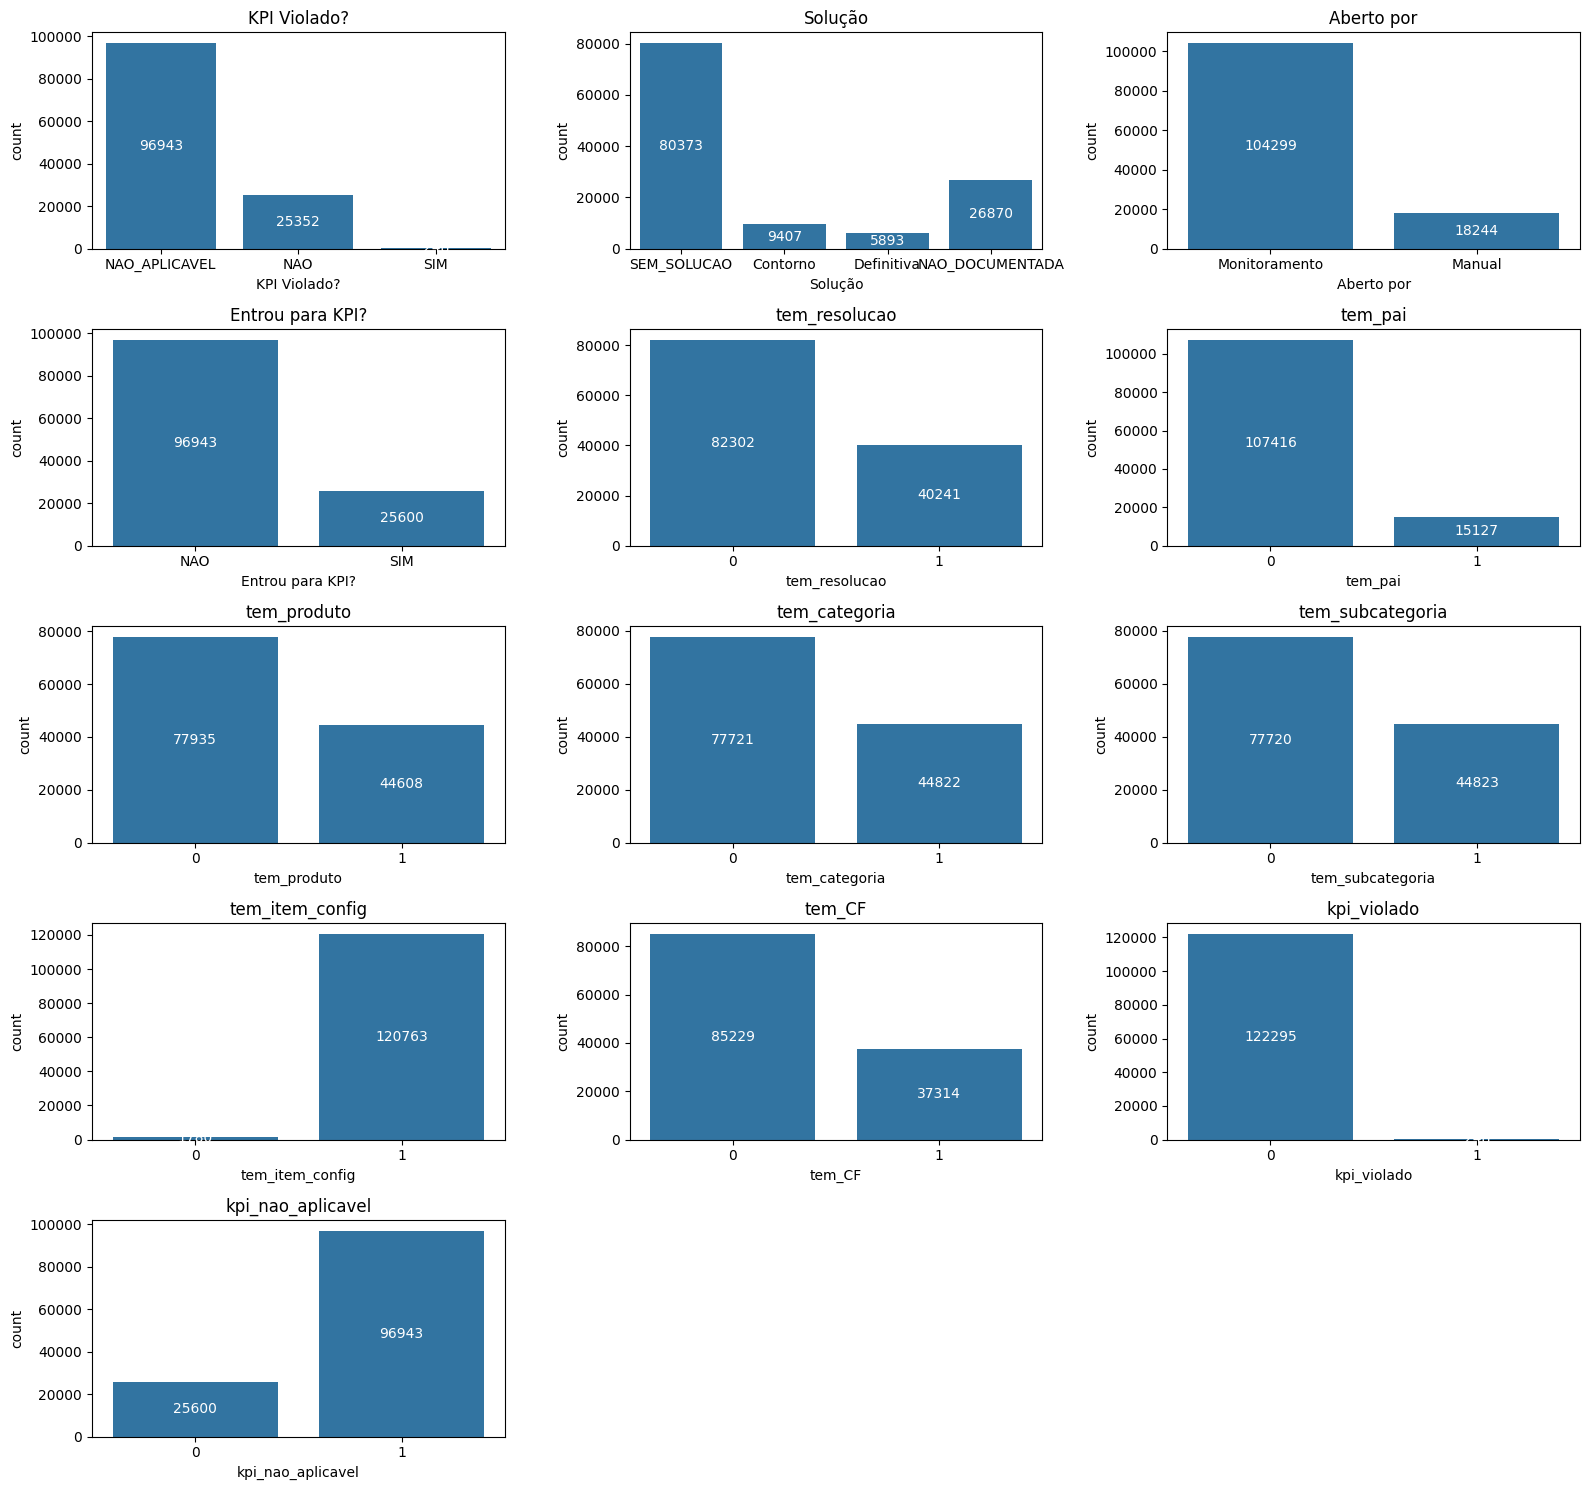

In [134]:
variaveis = [ 'KPI Violado?', 'Solução', 'Aberto por', 'Entrou para KPI?', 
             'tem_resolucao', 'tem_pai', 'tem_produto', 'tem_categoria', 
             'tem_subcategoria', 'tem_item_config', 'tem_CF', 'kpi_violado', 'kpi_nao_aplicavel']

plt.figure(figsize=(16, 15))
for i, col in enumerate(variaveis, 1):
    ax = plt.subplot(5, 3, i)
    sns.countplot(x=col, data=df, ax=ax)
    ax.set_title(col)
    for container in ax.containers:
        ax.bar_label(container, label_type='center', fmt='%d', color='white')

plt.tight_layout()
plt.show()

##### **Interpretação:** ^^
- A maioria dos incidentes não entra para o KPI
- Entre os incidentes que entram no KPI, a taxa de violação de SLA é extremamente baixa
- A abertura dos incidentes acontece mais por monitoramento
- Poucos incidentes possuem relacionamento hierárquico (Incidente Pai)
- A maioria dos incidentes não tiveram solução ou não tiveram solução documentada
    - A menor parte das soluções foram definitivas
- A maior parte da coluna de produtos, categoria e subcategorias não tem valor identificado
    - mesma coisa para codigo de fechamento

A maioria dos incidentes tem ``prioridade`` baixa ou média

In [135]:
df['Prioridade'].value_counts()

Prioridade
4 - Baixa          64828
3 - Média          41732
2 - Alta           15649
5 - Muito Baixa      333
1 - Crítica            1
Name: count, dtype: int64

A maior parte dos ``produtos`` é MONITORING_AUTO --> não é um produto

Portanto a maior parte de ``produtos`` é o lhco

In [136]:
df['Produto'].value_counts().head(10)

Produto
MONITORING_AUTO    77823
lhco               12835
lsin                7342
lcem                5878
lhvp                4454
lrev                3784
lcho                1368
lcsi                1085
lsaa                 919
lrel                 905
Name: count, dtype: int64

Maior parte dos ``status`` não tem intervenção

In [137]:
df['Status'].value_counts()

Status
Sem Intervenção              80373
Encerrado Automaticamente    26830
Encerrado                    15339
Aguardando Problema              1
Name: count, dtype: int64

Team14 é o ``grupo`` que cuida da maior parte dos incidentes

In [138]:
df['Grupo designado'].value_counts().head(10)

Grupo designado
Team14    92775
Team11     9790
Team05     9276
Team09     3425
Team12     2173
Team03     1306
Team10     1172
Team17      743
Team02      579
Team01      306
Name: count, dtype: int64

Em geral ``Item de configuração`` é balanceado, mas com predominância de IC00014    

In [139]:
df['Item de configuração'].value_counts().head(10)

Item de configuração
IC00014    6069
IC00019    4435
IC00008    4196
IC00349    3271
IC00002    3119
SEM_IC     1780
IC00325    1600
IC00004    1149
IC00604    1079
IC00725     988
Name: count, dtype: int64

A maior parte de ``categorias`` e ``subcategorias`` são de INFRA_Monitoramento --> não é categoria

In [140]:
df['Categoria'].value_counts().head(10)

Categoria
INFRA_Monitoramento    77717
cat71                   7335
cat77                   4425
cat85                   4319
cat76                   4304
cat73                   3388
cat31                   2483
cat137                  1716
cat91                   1246
cat36                   1086
Name: count, dtype: int64

In [141]:
df['Subcategoria'].value_counts().head(10)

Subcategoria
INFRA_Monitoramento_Geral    77717
sub7                          4668
sub336                        4297
sub36                         2741
sub387                        2494
sub427                        2192
sub225                        1638
sub392                        1625
sub127                        1470
sub438                        1116
Name: count, dtype: int64

A maior parte da coluna de ``Código de fechamento`` é composta por AUTO_SEM_INTERVENCAO 

In [142]:
df['Código de fechamento'].value_counts().head(10)

Código de fechamento
AUTO_SEM_INTERVENCAO            80373
Falha de Aplicação              20612
Falha de Sistema Operacional     5009
AUTO_ENCERRADO                   2434
NAO_DOCUMENTADO                  2422
Falha causada pelo cliente       1796
Sem retorno do solicitante       1527
Falha não reproduzida            1401
Incidente causado por Change     1353
Falha de Cloud                   1202
Name: count, dtype: int64

##### **Contínua:**

Duração (em segundos)

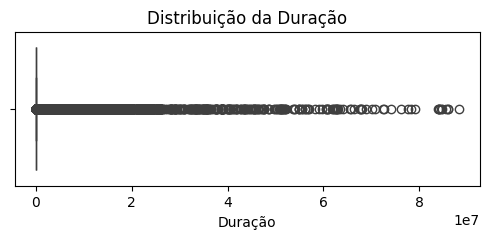

In [143]:
plt.figure(figsize=(6, 2))
sns.boxplot(x='Duração', data=df)
plt.title('Distribuição da Duração')
plt.show()

Tornando de melhor compreensão:

In [144]:
df['Duração'].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99])

count    1.225430e+05
mean     2.485470e+05
std      2.480123e+06
min      1.000000e+00
25%      2.630000e+02
50%      9.780000e+02
75%      4.240500e+03
90%      1.843480e+04
95%      1.010522e+05
99%      6.157757e+06
max      8.828048e+07
Name: Duração, dtype: float64

| Medida        |   Segundos | Aproximadamente       |
| ------------- | ---------: | --------------------- |
| Min           |          1 | 1 segundo             |
| 25%           |        263 | 4,4 min               |
| 50% (mediana) |        978 | 16,3 min              |
| 75%           |      4.240 | 1,18 h                |
| 90%           |     18.435 | 5,1 h                 |
| 95%           |    101.052 | 28,1 h                |
| 99%           |  6.157.757 | 71,3 dias             |
| Máx           | 88.280.480 | 1.022 dias (2,8 anos) |


In [145]:
df['duracao_log'] = np.log1p(df['Duração'])

### **Sazonalidade**

##### Evolução da Quantidade de Incidentes por Dia

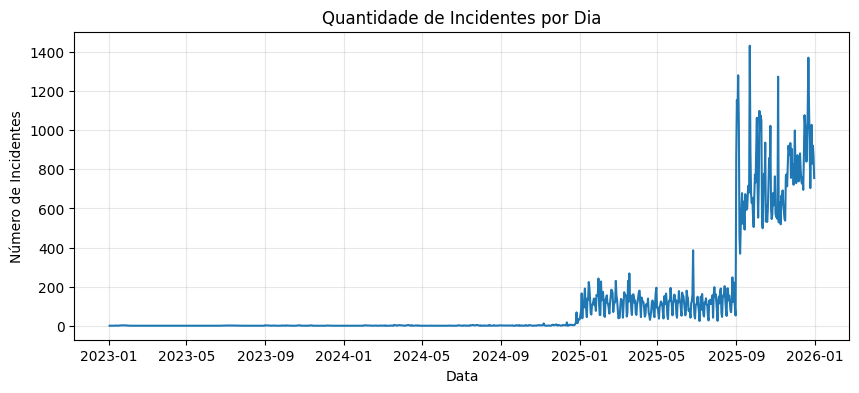

In [146]:
incidentes_dia = (df.groupby(df['Aberto'].dt.date).size())
plt.figure(figsize=(10,4))
incidentes_dia.plot()
plt.title('Quantidade de Incidentes por Dia')
plt.xlabel('Data')
plt.ylabel('Número de Incidentes')
plt.grid(True, alpha=0.3)
plt.show()

Principais insights ^^
- A partir do final de 2024/início de 2025 ocorre uma mudança brusca na quantidade de incidentes registrados (aumenta muito)
- Em setembro de 2025 há um novo salto expressivo no volume
- Após setembro de 2025, os incidentes passam a oscilar entre aproximadamente 500 e mais de 1.000 registros por dia.

##### Heatmap de Incidentes por Mês e Ano

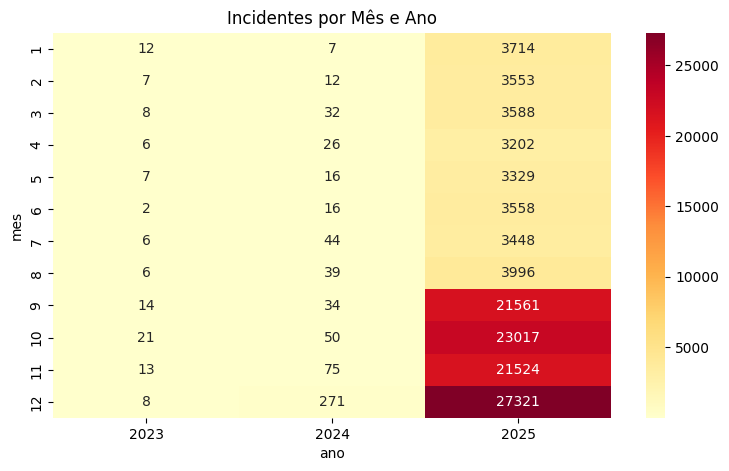

In [147]:
tmp = df.copy()
tmp['ano'] = tmp['Aberto'].dt.year
tmp['mes'] = tmp['Aberto'].dt.month

pivot_mes = pd.pivot_table(
    tmp,
    index='mes',
    columns='ano',
    values='Número',
    aggfunc='count'
)

plt.figure(figsize=(9,5))
sns.heatmap(pivot_mes, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Incidentes por Mês e Ano')
plt.show()

Principais insights ^^
- 2023 apresenta volume muito reduzido de incidentes
- 2024 mostra crescimento gradual, especialmente no segundo semestre
- O volume cresce fortemente em 2025
- Setembro, Outubro, Novembro e Dezembro de 2025 concentram os maiores volumes registrados.

##### Quantidade de Incidentes por Dia da Semana

C:\Users\IsabellaHeder\AppData\Local\Temp\ipykernel_28140\2432216178.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[dias_semana[i] for i in range(7)], y=incidentes_semana.values, palette='Blues_r')


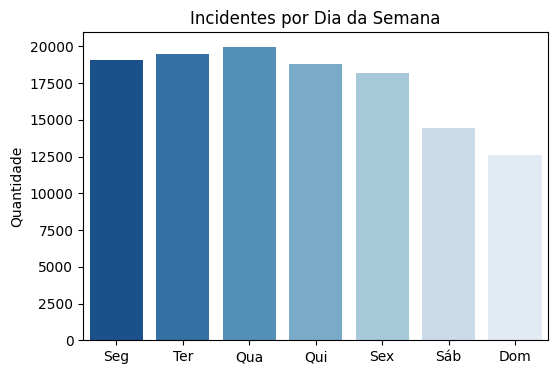

In [148]:
dias_semana = {0:'Seg', 1:'Ter', 2:'Qua', 3:'Qui', 4:'Sex', 5:'Sáb', 6:'Dom'}
tmp['dia_semana'] = tmp['Aberto'].dt.dayofweek
incidentes_semana = (tmp.groupby('dia_semana').size().reindex(range(7)))

plt.figure(figsize=(6,4))
sns.barplot(x=[dias_semana[i] for i in range(7)], y=incidentes_semana.values, palette='Blues_r')

plt.title('Incidentes por Dia da Semana')
plt.ylabel('Quantidade')
plt.show()

Principais insights ^^
- Quarta-feira apresenta a maior quantidade de incidentes da semana.
- Segunda, terça e quinta-feira possuem volumes semelhantes e elevados.
- Há queda significativa nos finais de semana.
- Domingo é o dia com menor volume de incidentes.

##### Quantidade de Incidentes por Hora do Dia

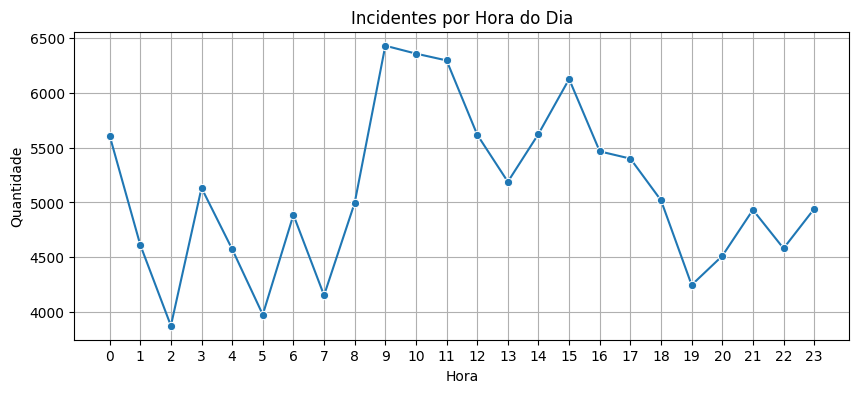

In [149]:
tmp['hora'] = tmp['Aberto'].dt.hour
incidentes_hora = (tmp.groupby('hora').size().reindex(range(24), fill_value=0))

plt.figure(figsize=(10,4))
sns.lineplot(x=incidentes_hora.index, y=incidentes_hora.values,marker='o')

plt.title('Incidentes por Hora do Dia')
plt.xlabel('Hora')
plt.ylabel('Quantidade')
plt.xticks(range(24))
plt.grid(True)
plt.show()

Principais insights ^^
- O volume de incidentes é menor durante a madrugada (entre 2h e 5h)
- A partir das 8h ocorre um crescimento significativo
- O pico máximo acontece entre 9h e 11h
- segundo pico relevante por volta das 15h
- Após as 18h observa-se redução

##### Heatmap de Incidentes por Dia da Semana e Hora

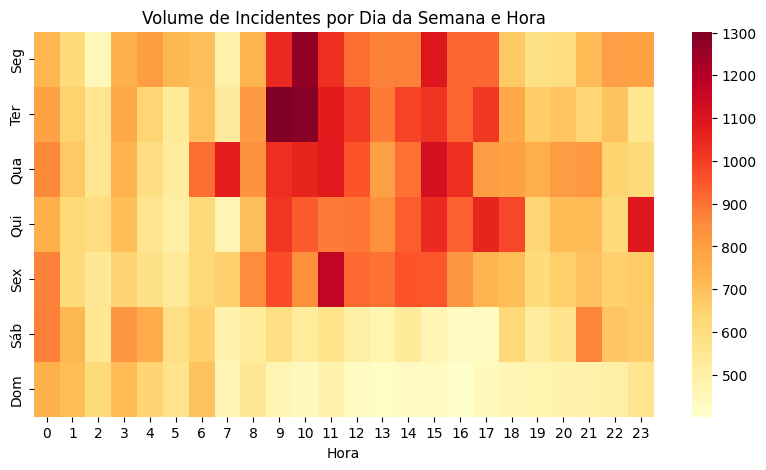

In [150]:
heatmap_data = pd.pivot_table(tmp, index='dia_semana', columns='hora', values='Número', aggfunc='count', fill_value=0)
heatmap_data.index = ['Seg','Ter','Qua','Qui','Sex','Sáb','Dom']

plt.figure(figsize=(10,5))
sns.heatmap(heatmap_data, cmap='YlOrRd')
plt.title('Volume de Incidentes por Dia da Semana e Hora')
plt.xlabel('Hora')
plt.ylabel('')
plt.show()

Principais insights ^^
- maiores volumes concentram-se entre terça e quinta-feira
- entre 9h e 17h apresenta a maior incidência
- Quarta-feira mantém volume elevado durante quase todo o horário comercial
- Quinta-feira tem incidentes 23h
- Sábado e domingo apresentam volume significativamente menor em todas as horas.

### Correlação entre Variáveis

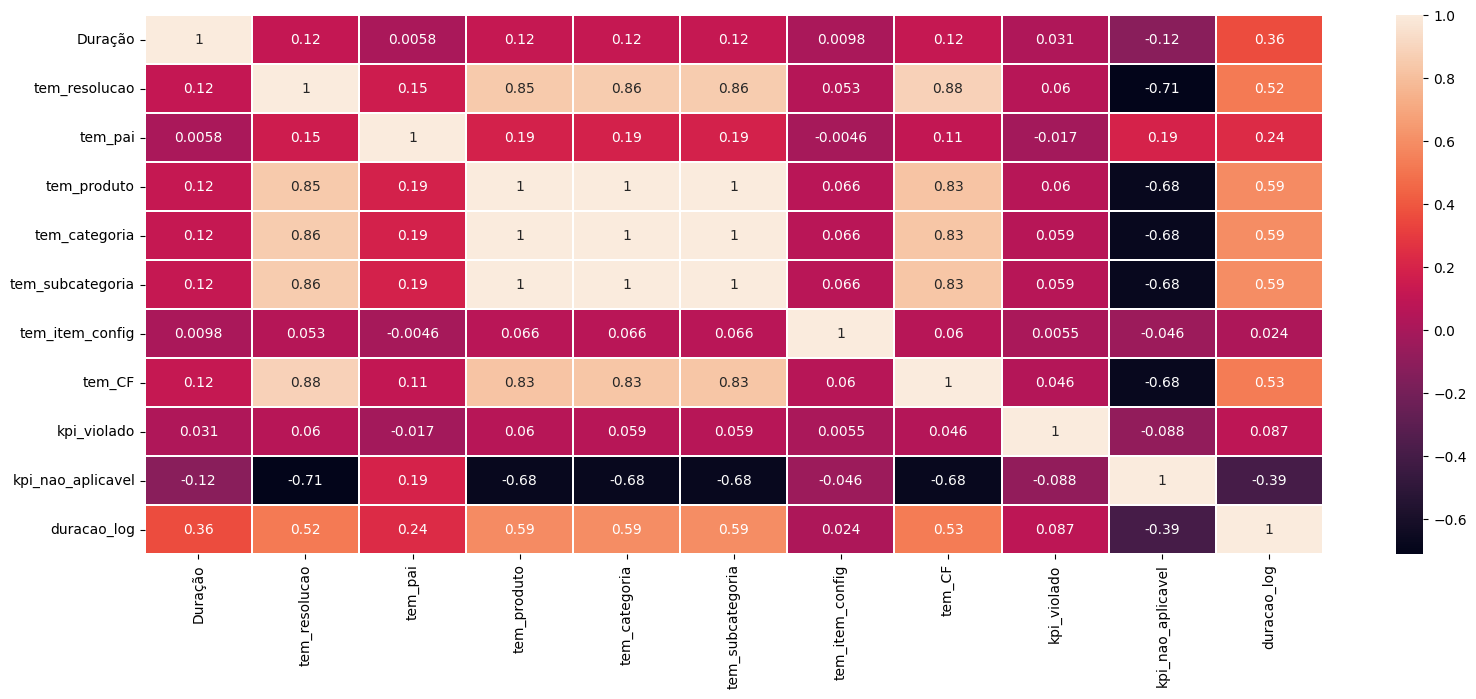

In [151]:
matriz_correlacao = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(19, 7))
sns.heatmap(matriz_correlacao, annot = True, linewidths = 0.2)
plt.show()

- tem_produto, tem_categoria e tem_subcategoria possuem correlação praticamente perfeita (≈ 1,00) -- redundantes
- tem_CF apresenta forte correlação com tem_resolucao (0,88) 
    - inc. resolvidos tendem a possuir código de fechamento registrado
- tem_resolucao também possui forte correlação com Produto, Categoria e Subcategoria 
    - informações completas tendem a possuir resolução documentada
- kpi_nao_aplicavel apresenta forte correlação negativa com tem_resolucao 
    - inc. fora do KPI tendem a ter menos informações de resolução registradas.
- duracao_log possui correlação moderada com Produto, Categoria e Subcategoria 
    - cadastro mais completo tendem a estar associados a maiores tempos de duração

_______________
### Feature Engineering 1

Eu testei uma variedade de features diferentes, e essas foram as que trouxeram o melhor desempenho do modelo

``Feature temporal``

In [247]:
df['mes'] = df['Aberto'].dt.month

``Feature de texto (a partir da Descrição resumida)``

In [248]:
df['Descrição resumida'].value_counts().head()

Descrição resumida
Problem: Check Application Monitoring                    28728
Problem: Free disk space is less than 10% on volume /     4770
Problem: Check Application Monitoring VIP                 4281
Problem: Unavailable by ICMP ping                         4133
Problem: Apache Busy Workers                              3925
Name: count, dtype: int64

In [249]:
df['tem_AM'] = df['Descrição resumida'].str.contains('Application Monitoring', case=False, na=False).astype(int)

_____________
### Correlação entre novas variáveis

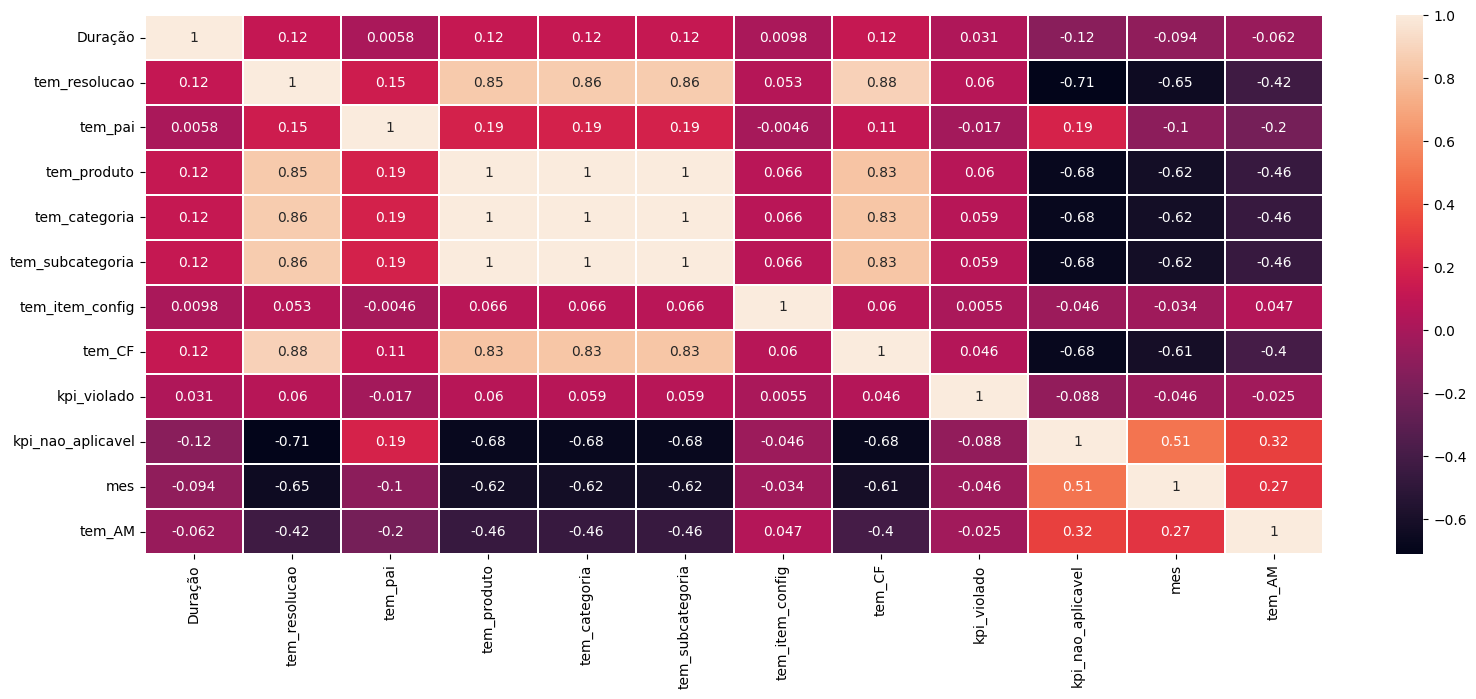

In [250]:
matriz_correlacao = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(19, 7))
sns.heatmap(matriz_correlacao, annot = True, linewidths = 0.2)
plt.show()

### Modelo Preditivo D+1 e D+7

Para prever volume de incidentes futuros (D+1 e D+7), a unidade de análise não deve mais ser o incidente individual, mas sim o dia.

Para o forecast preciso transformar o dataset atual em:
| Data       | qtd\_incidentes |
| ---------- | --------------: |
| 2024-01-01 |             237 |
| 2024-01-02 |             198 |
| 2024-01-03 |             214 |

Passo 1: criar série diária

In [396]:
df_model = df[df['Aberto'] >= '2025-01-01'].copy()
serie = (df_model.groupby(df_model['Aberto'].dt.date).size().reset_index(name='qtd_incidentes'))
serie.columns = ['data', 'qtd_incidentes']
serie['data'] = pd.to_datetime(serie['data'])

Passo 2: Agregar informações úteis do dia

In [ ]:
indicadores = (df.groupby(df['Aberto'].dt.date).agg({'tem_AM':'mean'}).reset_index().rename(columns={'Aberto': 'data'}))

In [398]:
serie['data'] = pd.to_datetime(serie['data'])
indicadores['data'] = pd.to_datetime(indicadores['data'])

Passo 3: Juntar tudo

In [399]:
serie = serie.merge(indicadores, on='data')

Passo 4: Criar features de séries temporais
- Lags

In [400]:
serie['lag_1'] = serie['qtd_incidentes'].shift(1)
serie['lag_7'] = serie['qtd_incidentes'].shift(7)

Médias móveis

In [401]:
serie['media_7d'] = serie['qtd_incidentes'].rolling(7).mean()

In [491]:
serie.head()

,data,qtd_incidentes,tem_AM,lag_1,lag_7,media_7d,mes,dia_semana,target_d1,target_d7,lag_2,lag_14,lag_30,media_14d,media_30d,std_7d,media_3d,trend_7_30,variacao_1d,variacao_7d
0,2025-01-01,34,0.06,NaN,NaN,NaN,1,2,55.00,144.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-02,55,0.04,34.00,NaN,NaN,1,3,77.00,191.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-01-03,77,0.00,55.00,NaN,NaN,1,4,166.00,98.00,34.00,NaN,NaN,NaN,NaN,NaN,55.33,NaN,21.00,NaN
3,2025-01-04,166,0.00,77.00,NaN,NaN,1,5,39.00,84.00,55.00,NaN,NaN,NaN,NaN,NaN,99.33,NaN,22.00,NaN
4,2025-01-05,39,0.05,166.00,NaN,NaN,1,6,115.00,45.00,77.00,NaN,NaN,NaN,NaN,NaN,94.00,NaN,89.00,NaN


Passo 5: Calendário

In [403]:
serie['mes'] = serie['data'].dt.month
serie['dia_semana'] = serie['data'].dt.dayofweek

Passo 6: Criar os alvos

In [404]:
serie['target_d1'] = serie['qtd_incidentes'].shift(-1)
serie['target_d7'] = serie['qtd_incidentes'].shift(-7)

In [405]:
serie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   data            365 non-null    datetime64[ns]
 1   qtd_incidentes  365 non-null    int64         
 2   tem_AM          365 non-null    float64       
 3   lag_1           364 non-null    float64       
 4   lag_7           358 non-null    float64       
 5   media_7d        359 non-null    float64       
 6   mes             365 non-null    int32         
 7   dia_semana      365 non-null    int32         
 8   target_d1       364 non-null    float64       
 9   target_d7       358 non-null    float64       
dtypes: datetime64[ns](1), float64(6), int32(2), int64(1)
memory usage: 25.8 KB


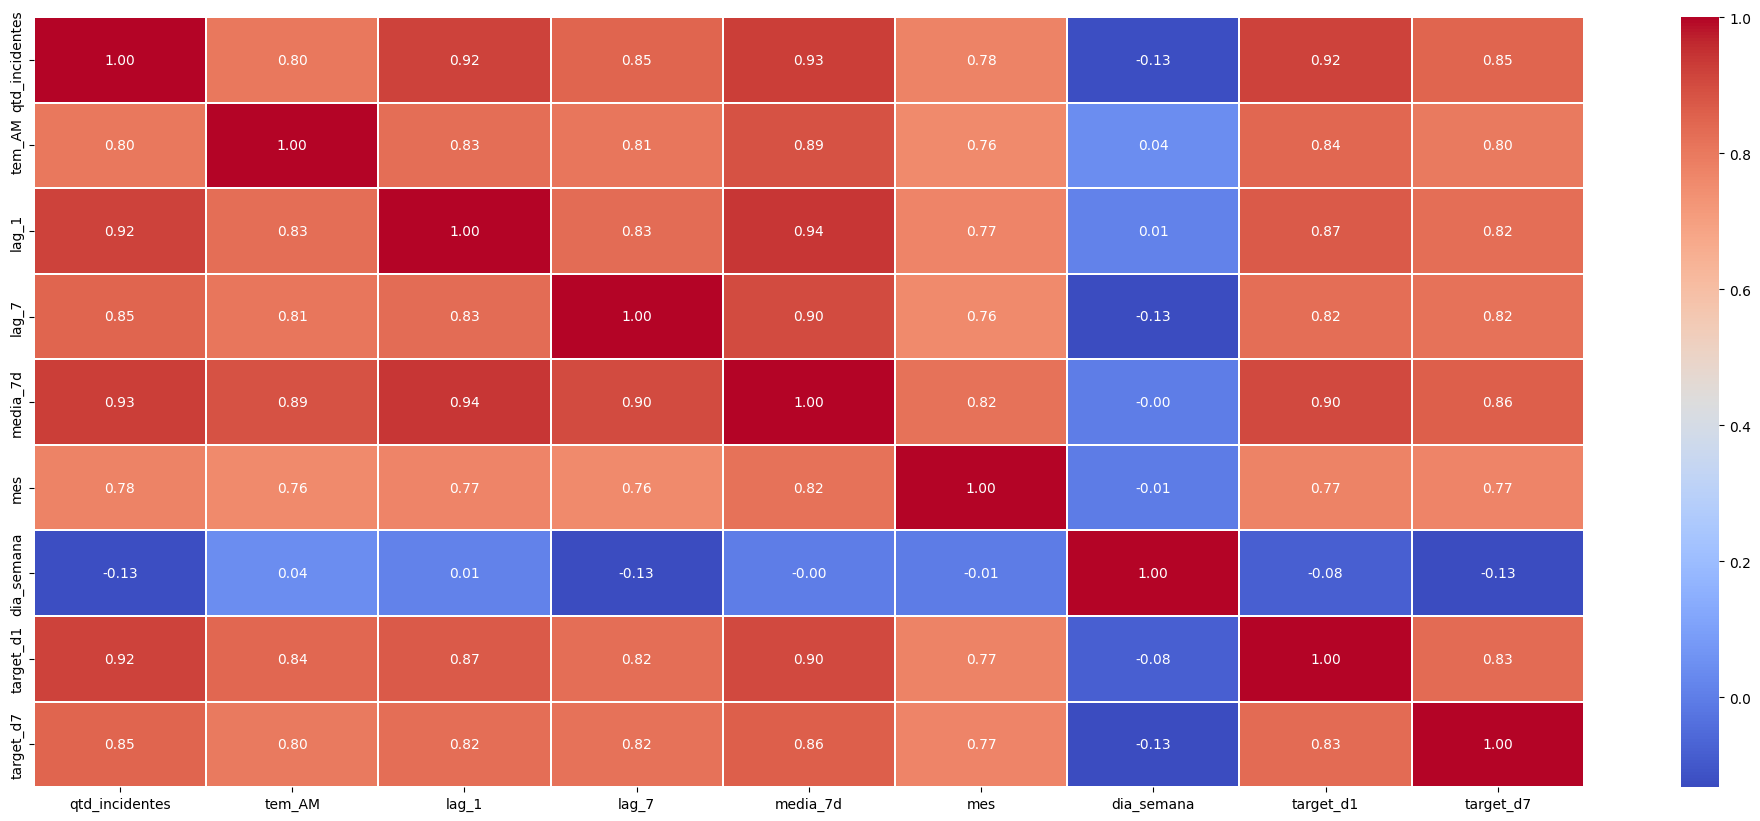

In [406]:
matriz_correlacao = serie.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(25, 10))
sns.heatmap(matriz_correlacao, annot = True, linewidths = 0.2, cmap='coolwarm', fmt='.2f')
plt.show()

Interpretação:

| Feature             | Corr com target\_d1 |
| ------------------- | ------------------- |
| lag\_1              | 0.86                |
| media\_7d           | 0.90                |
| tem\_AM             | 0.85                |
| lag\_7              | 0.82                |

##
| Feature             | Corr com target\_d7 |
| ------------------- | ------------------- |
| media\_7d           | 0.86                |
| lag\_1              | 0.82                |
| lag\_7              | 0.82                |
| tem\_AM             | 0.80                |

Essas foram outras features que eu criei, mas que **não utilizei no modelo** (apesar de terem correlação)
- modelo performou melhor sem elas

In [407]:
serie['lag_2'] = serie['qtd_incidentes'].shift(2)
serie['lag_14'] = serie['qtd_incidentes'].shift(14)
serie['lag_30'] = serie['qtd_incidentes'].shift(30)
serie['media_14d'] = serie['qtd_incidentes'].rolling(14).mean()
serie['media_30d'] = serie['qtd_incidentes'].rolling(30).mean()
serie['std_7d'] = serie['qtd_incidentes'].rolling(7).std()
serie['media_3d'] = serie['qtd_incidentes'].rolling(3).mean()
serie['trend_7_30'] = serie['media_7d'] - serie['media_30d']
serie['variacao_1d'] = serie['lag_1'] - serie['lag_2']
serie['variacao_7d'] = serie['lag_1'] - serie['lag_7']

Removendo linhas com NaN gerados pelos lags e targets:
- os NaNs são criados por conta de que não existe valor antes do primeiro do dataset (ou dos 7 primeiros etc)

In [408]:
serie_model = serie.dropna().copy()
len(serie_model)

328

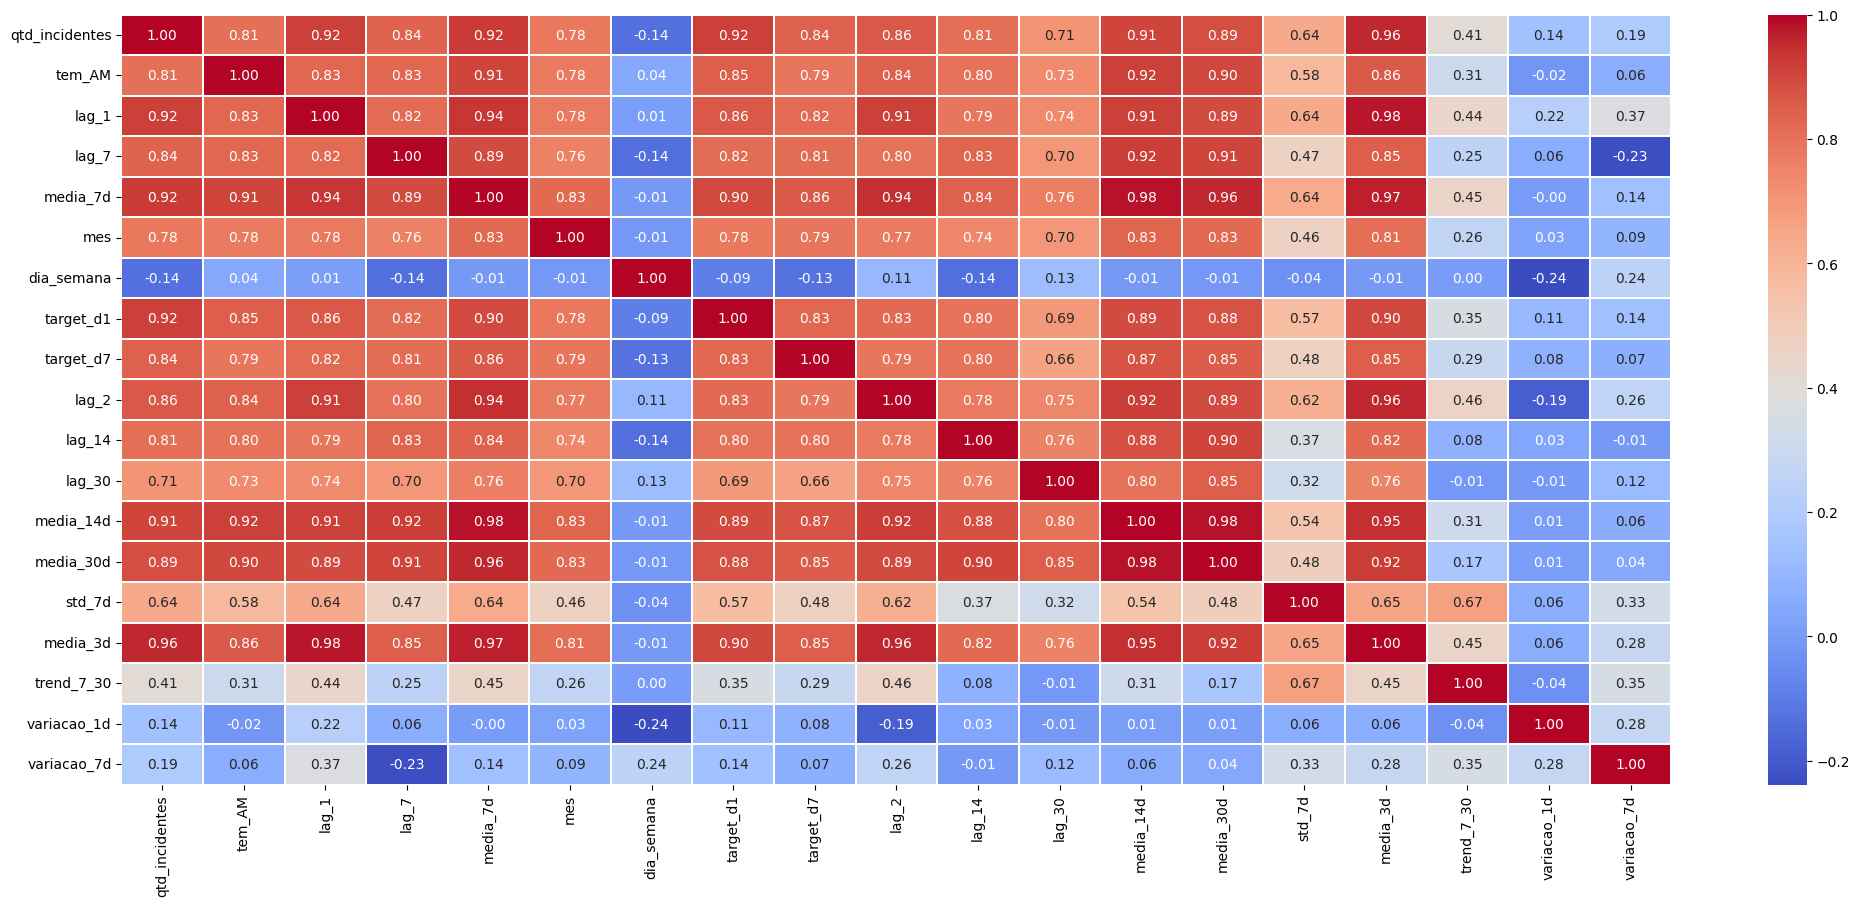

In [409]:
matriz_correlacao = serie_model.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(25, 10))
sns.heatmap(matriz_correlacao, annot = True, linewidths = 0.2, cmap='coolwarm', fmt='.2f')
plt.show()

Vou salvar o dataset para utilizar em sprints de outros professores

In [410]:
serie_model.to_csv('serie_temporal_incidentes.csv', index=False)

#### Teste de features:

O teste foi feito com o melhor modelo encontrado para esse caso (gradient boosting)

| Features | MAE | RMSE | R2 |
|----------|-----|------|----|
| 'lag_1', 'lag_2', 'lag_7', 'media_7d', 'tem_AM', 'mes' | 118 | 157 | 0.23 |
| 'lag_1', 'lag_7', 'media_7d', 'tem_AM', 'mes' | 106 | 142 | 0.37 | 
| 'lag_1', 'lag_2', 'lag_14', 'lag_7', 'media_7d', 'tem_AM', 'mes'  | 114 | 157 | 0.23 |
| 'lag_1', 'lag_7', 'media_7d', 'media_3d', 'tem_AM', 'mes' | 118 | 163 | 0.17 |
| 'lag_1', 'lag_7', 'media_7d', 'media_14d' ,'tem_AM', 'mes' | 155 | 205 | -0.29 |
| 'tem_AM', 'media_3d', 'media_14d', 'media_30d', 'mes', 'dia_semana' | 173 | 235 | -0.71 |
| 'lag_1', 'lag_7', 'media_7d', 'media_30d' ,'tem_AM', 'mes' | 135 | 179 | 0.00 |
| 'lag_1', 'lag_7', 'media_7d', 'trend_7_30' ,'tem_AM', 'mes' | 106 | 144 | 0.35 |
| 'lag_1', 'lag_7', 'media_7d', 'std_7d', 'tem_AM', 'mes' | 119 | 162 | 0.18 |
| 'lag_1', 'lag_7', 'media_7d', 'std_7d', 'tem_AM', 'mes', 'trend_7_30' | 122| 169 | 0.11 |
| 'lag_1', 'lag_7', 'media_7d', 'tem_AM' | 107 | 144 | 0.35 |

Features finais:

In [411]:
features = ['lag_1', 'lag_7', 'media_7d', 'tem_AM', 'mes']

``Separação temporal``

In [412]:
split = int(len(serie_model) * 0.8)

train = serie_model.iloc[:split]
test = serie_model.iloc[split:]

### Modelo D+1

| Algoritmo testado | MAE | RMSE | R2 |
|---------------------|---------|---------|---------|
| GradientBoostingRegressor | **106.19** | **142.32** | **0.375** |
| XGBRegressor | 123.76 | 162.79 | 0.182 |
| RandomForestRegressor | 125.54 | 160.48 | 0.205 |
| AdaBoostRegressor | 135.95 | 178.14 | 0.021 |
| ExtraTreesRegressor | 137.35 | 175.55 | 0.049 |

In [413]:
X_train = train[features]
X_test = test[features]

y_train = train['target_d1']
y_test = test['target_d1']

Gradient Boosting Regressor

In [414]:
from sklearn.ensemble import GradientBoostingRegressor
model_d1 = GradientBoostingRegressor(n_estimators=100, max_depth=4, learning_rate=0.03, random_state=42)

model_d1.fit(X_train, y_train)
pred_d1 = model_d1.predict(X_test)

print('MAE:', mean_absolute_error(y_test, pred_d1))
print('RMSE:', np.sqrt(mean_squared_error(y_test, pred_d1)))
print('R²:', r2_score(y_test, pred_d1))

mape = np.mean(np.abs((y_test - pred_d1) / y_test)) * 100
print(f'MAPE: {mape:.2f}%')

MAE: 106.19048479581187
RMSE: 142.31539629278473
R²: 0.37498421731306764
MAPE: 13.64%


### Modelo D+7

Teste de Features:
| Features | MAE | RMSE | R2 |
|----------|-----|------|----|
| 'lag_1', 'lag_7', 'media_7d', 'tem_AM' | 133 | 170 | 0.08 |
| 'lag_1', 'lag_7', 'media_7d', 'tem_AM', 'mes' | 128 | 165 | 0.12 |
| 'lag_1', 'lag_7', 'media_7d', 'trend_7_30' ,'tem_AM', 'mes' | 145 | 177 | 0.0 | 
| 'lag_1', 'lag_2', 'lag_7', 'media_7d', 'tem_AM', 'mes'  | 128 | 165 | 0.13 |
| 'lag_1', 'lag_2', 'lag_14', 'lag_7', 'media_7d', 'tem_AM', 'mes' | 131 | 165 | 0.12 |

In [415]:
features = ['lag_1', 'lag_7', 'media_7d', 'tem_AM', 'mes']
X_train = train[features]
X_test = test[features]

y_train = train['target_d7']
y_test = test['target_d7']

Teste de Modelos

| Algoritmo | MAE | RMSE | R² |
|-----------|---------|---------|---------|
| GradientBoostingRegressor | **128.60** | **165.83** | **0.129** |
| RandomForestRegressor | 132.13 | 167.54 | 0.111 |
| ExtraTreesRegressor | 131.99 | 172.69 | 0.056 |
| XGBRegressor | 136.37 | 175.94 | 0.020 |
| HistGradientBoostingRegressor | 142.35 | 185.56 | -0.090 |

In [416]:
model_d7 = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=2,
    learning_rate=0.05, 
    random_state=42)

model_d7.fit(X_train, y_train)
pred_d7 = model_d7.predict(X_test)

print('MAE:', mean_absolute_error(y_test, pred_d7))
print('RMSE:', np.sqrt(mean_squared_error(y_test, pred_d7)))
print('R²:', r2_score(y_test, pred_d7))

mape = np.mean(np.abs((y_test - pred_d7) / y_test)) * 100
print(f'MAPE: {mape:.2f}%')

pd.DataFrame({
    'feature': features,
    'importance': model_d7.feature_importances_
}).sort_values('importance', ascending=False)

MAE: 128.59880669498216
RMSE: 165.829596872635
R²: 0.129299133652662
MAPE: 16.15%


,feature,importance
0,lag_1,0.56
4,mes,0.18
2,media_7d,0.15
1,lag_7,0.10
3,tem_AM,0.01


## Previsão de Incidentes por Prioridade

In [421]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge

features = ['lag_1', 'lag_7', 'media_7d', 'tem_AM', 'mes', 'dow']
usa_ridge = {'3 - Média'}   # Ridge vence só na Média; HistGB (estável) no resto

In [422]:
df_base = df[df['Aberto'] >= '2025-01-01'].copy()

def montar_serie(df_p):
    g = df_p.groupby(df_p['Aberto'].dt.date)
    d = pd.DataFrame({'qtd_incidentes': g.size(), 'tem_AM': g['tem_AM'].mean()})
    d.index = pd.to_datetime(d.index)
    d = d.reindex(pd.date_range(d.index.min(), d.index.max(), freq='D'),
                  fill_value=0).rename_axis('data').reset_index()
    d['lag_1']    = d['qtd_incidentes'].shift(1)
    d['lag_7']    = d['qtd_incidentes'].shift(7)
    d['media_7d'] = d['qtd_incidentes'].rolling(7).mean()
    d['mes']      = d['data'].dt.month
    d['dow']      = d['data'].dt.dayofweek
    d['target_d1'] = d['qtd_incidentes'].shift(-1)
    d['target_d7'] = d['qtd_incidentes'].shift(-7)
    return d.dropna().copy()

In [423]:
def avaliar(serie_model, target, prio):
    split = int(len(serie_model) * 0.8)
    train, test = serie_model.iloc[:split], serie_model.iloc[split:]
    if len(test) < 5:
        return None
    if prio in usa_ridge:
        model = Ridge(alpha=1.0)
    else:
        model = HistGradientBoostingRegressor(max_depth=3, learning_rate=0.05, random_state=42)
    model.fit(train[features], train[target])
    pred = model.predict(test[features])
    y = test[target].values
    mask = y != 0
    return {'MAE': mean_absolute_error(y, pred),
            'RMSE': np.sqrt(mean_squared_error(y, pred)),
            'R2': r2_score(y, pred),
            'MAPE': np.mean(np.abs((y[mask] - pred[mask]) / y[mask])) * 100 if mask.any() else np.nan,
            'modelo': type(model).__name__.replace('Regressor', '')}

ordem = ['1 - Crítica', '2 - Alta', '3 - Média', '4 - Baixa', '5 - Muito Baixa']
for prio in [p for p in ordem if p in df_base['Prioridade'].unique()]:
    serie_model = montar_serie(df_base[df_base['Prioridade'] == prio])
    if len(serie_model) < 40:
        print(f'\n===== {prio} ===== dados insuficientes ({len(serie_model)} dias) — pulado')
        continue
    print(f'\n===== {prio} =====')
    for target, nome in [('target_d1', 'D+1'), ('target_d7', 'D+7')]:
        m = avaliar(serie_model, target, prio)
        print(f'[{nome}] {m["modelo"]:20s} MAE: {m["MAE"]:.2f} | RMSE: {m["RMSE"]:.2f} | '
              f'R²: {m["R2"]:.3f} | MAPE: {m["MAPE"]:.2f}%')


===== 1 - Crítica ===== dados insuficientes (0 dias) — pulado

===== 2 - Alta =====
[D+1] HistGradientBoosting MAE: 50.32 | RMSE: 95.94 | R²: -0.043 | MAPE: 53.83%
[D+7] HistGradientBoosting MAE: 48.84 | RMSE: 83.69 | R²: 0.087 | MAPE: 74.72%

===== 3 - Média =====
[D+1] Ridge                MAE: 63.08 | RMSE: 88.79 | R²: 0.373 | MAPE: 33.12%
[D+7] Ridge                MAE: 85.59 | RMSE: 121.32 | R²: 0.125 | MAPE: 37.15%

===== 4 - Baixa =====
[D+1] HistGradientBoosting MAE: 66.91 | RMSE: 87.99 | R²: 0.041 | MAPE: 15.15%
[D+7] HistGradientBoosting MAE: 82.78 | RMSE: 102.76 | R²: -0.276 | MAPE: 17.33%

===== 5 - Muito Baixa =====
[D+1] HistGradientBoosting MAE: 0.33 | RMSE: 0.53 | R²: 0.007 | MAPE: 82.37%
[D+7] HistGradientBoosting MAE: 0.34 | RMSE: 0.49 | R²: 0.034 | MAPE: 71.12%


_____________
## **Previsão de Risco de Perda de OLA por Incidente**

Modelo de Classificação

In [65]:
df.head()

,Número,Prioridade,Produto,Categoria,Subcategoria,Grupo designado,Item de configuração,Aberto,Resolvido,Encerrado,Duração,Código de fechamento,Descrição resumida,Solução,Aberto por,Incidente Pai,Status,Entrou para KPI?,KPI Violado?,tem_resolucao,tem_pai,tem_produto,tem_categoria,tem_subcategoria,tem_item_config,tem_CF,kpi_violado,kpi_nao_aplicavel,duracao_log,mes,tem_AM
0,INC8654273,3 - Média,MONITORING_AUTO,INFRA_Monitoramento,INFRA_Monitoramento_Geral,Team14,IC00001,2025-12-31 23:45:18,2025-12-31 23:45:32,2025-12-31 23:45:32,14,AUTO_SEM_INTERVENCAO,Problem: Apache Busy Workers,SEM_SOLUCAO,Monitoramento,NaN,Sem Intervenção,NAO,NAO_APLICAVEL,0,0,0,0,0,1,0,0,1,2.708050,12,0
1,INC8654270,4 - Baixa,MONITORING_AUTO,INFRA_Monitoramento,INFRA_Monitoramento_Geral,Team14,IC00002,2025-12-31 23:39:36,2025-12-31 23:43:05,2025-12-31 23:43:05,209,AUTO_SEM_INTERVENCAO,Problem: Check Application Monitoring,SEM_SOLUCAO,Monitoramento,NaN,Sem Intervenção,NAO,NAO_APLICAVEL,0,0,0,0,0,1,0,0,1,5.347108,12,1
2,INC8654264,4 - Baixa,MONITORING_AUTO,INFRA_Monitoramento,INFRA_Monitoramento_Geral,Team14,SEM_IC,2025-12-31 23:23:10,2025-12-31 23:25:00,2025-12-31 23:25:00,110,AUTO_SEM_INTERVENCAO,"Problem: Alarm Application Monitoring database Message: HTTPSConnectionPool(host='centraldoclienteIC04172locawebIC04172comIC04172br', port=443): Read timed out. (read timeout=25)",SEM_SOLUCAO,Monitoramento,NaN,Sem Intervenção,NAO,NAO_APLICAVEL,0,0,0,0,0,0,0,0,1,4.709530,12,1
3,INC8654263,4 - Baixa,MONITORING_AUTO,INFRA_Monitoramento,INFRA_Monitoramento_Geral,Team14,SEM_IC,2025-12-31 23:23:07,2025-12-31 23:24:57,2025-12-31 23:24:57,110,AUTO_SEM_INTERVENCAO,"Problem: Alarm Application Monitoring coupons Message: HTTPSConnectionPool(host='centraldoclienteIC04172locawebIC04172comIC04172br', port=443): Read timed out. (read timeout=25)",SEM_SOLUCAO,Monitoramento,NaN,Sem Intervenção,NAO,NAO_APLICAVEL,0,0,0,0,0,0,0,0,1,4.709530,12,1
4,INC8654262,4 - Baixa,MONITORING_AUTO,INFRA_Monitoramento,INFRA_Monitoramento_Geral,Team14,IC00003,2025-12-31 23:23:05,2025-12-31 23:23:47,2025-12-31 23:23:47,42,AUTO_SEM_INTERVENCAO,Problem: Check Application Monitoring,SEM_SOLUCAO,Monitoramento,NaN,Sem Intervenção,NAO,NAO_APLICAVEL,0,0,0,0,0,1,0,0,1,3.761200,12,1


##### Estamos tratando de uma variável **target extremamente desbalanceada**

Por isso, nestes caso, eu gosto de usar undersampling e class_weight=balanced (nos modelos que permitem)

In [66]:
df['kpi_violado'].value_counts()

kpi_violado
0    122295
1       248
Name: count, dtype: int64

In [67]:
df_kpi = df.copy()

Para o treino deste modelo existe uma série de features que DEVEM FICAR DE FORA (pois configuram data leak) e outras features que não deveriam entrar por não agregarem muito ao modelo (vou filtrar e elas vão se tornar inúteis):
- Primeiramente vou filtrar o dataset por 'Entrou para KPI?'] == 'SIM', filtrando assim algumas features se tornariam inúteis:
    - kpi_nao_aplicavel
    - tem_pai --> as que tem não entram pra kpi
    - 'Entrou para KPI?' --> usei só para filtrar
    - 'Incidente Pai' --> se tem pai, não entra no kpi

Além disso, existem features que não agregam valor por si próprias:
- 'Número' --> id, sem valor preditivo


In [68]:
df_kpi = df[df['Entrou para KPI?'] == 'SIM'].copy()
y = df_kpi['kpi_violado']

In [69]:
colunas_remover = [
    # leak
    'Resolvido','Encerrado','Duração','duracao_log','Código de fechamento',
    'Solução','Status','tem_resolucao','tem_CF',
    # não úteis por conta do filtro
    'KPI Violado?','Entrou para KPI?','kpi_nao_aplicavel','Incidente Pai','tem_pai',
    # sem valor
    'Número',
    # texto livre (sem NLP)
    'Descrição resumida']

X = df_kpi.drop(columns=colunas_remover)

X['hora_abertura'] = df_kpi['Aberto'].dt.hour
X['dia_semana']    = df_kpi['Aberto'].dt.dayofweek
X['fim_de_semana'] = (df_kpi['Aberto'].dt.dayofweek >= 5).astype(int)
X = X.drop(columns=['Aberto'])

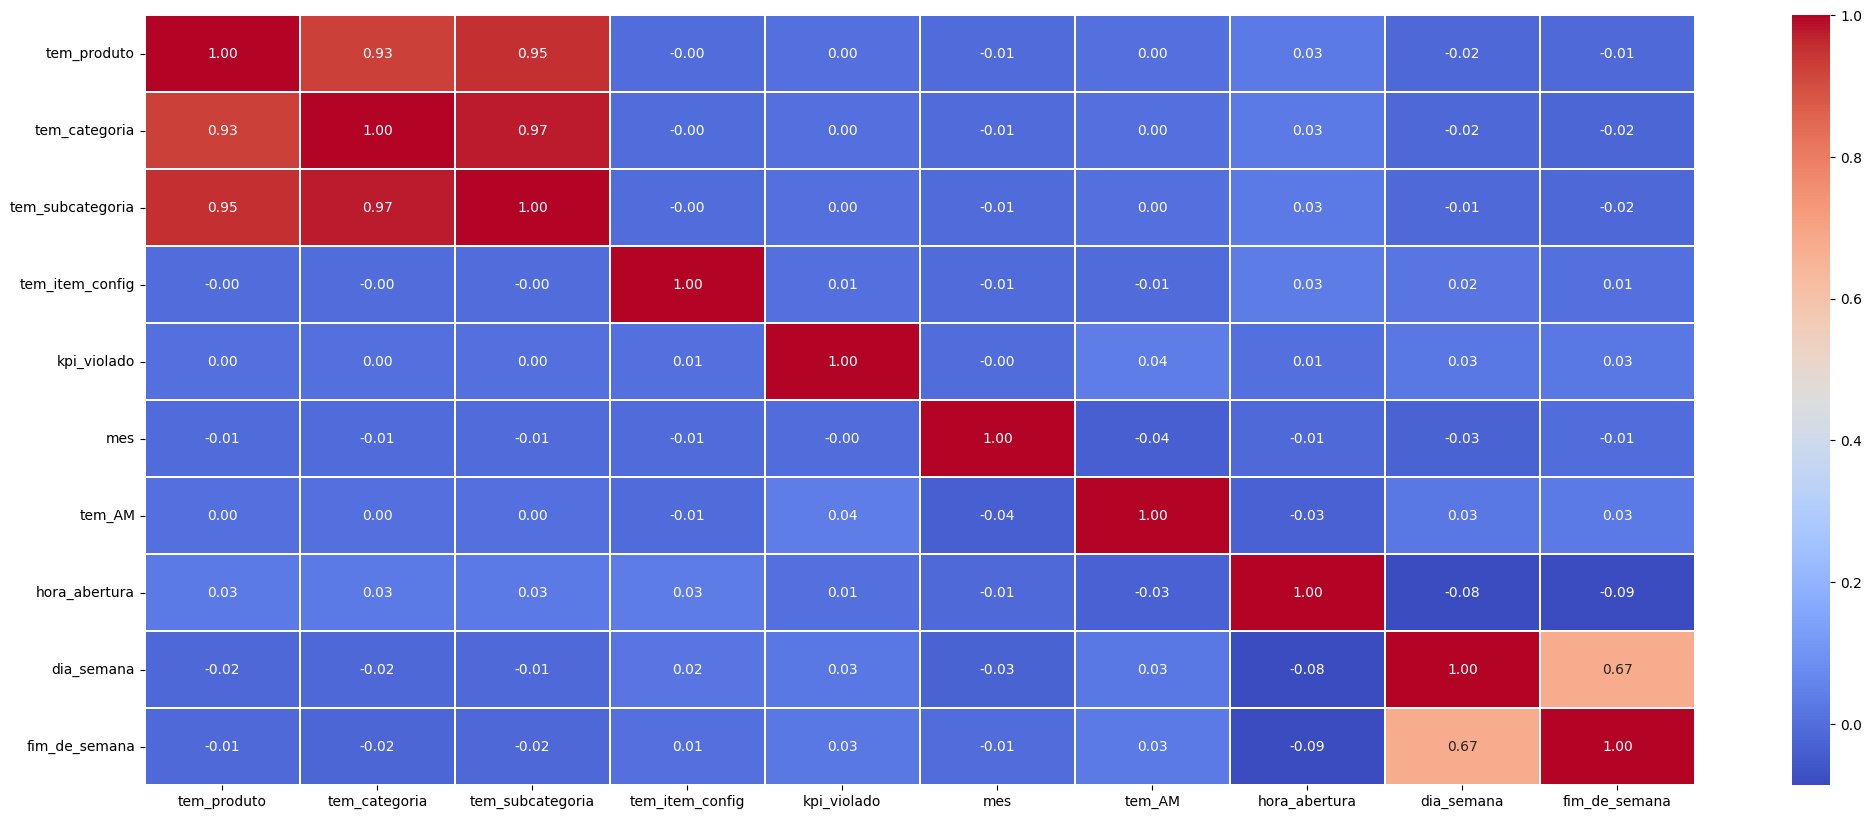

In [70]:
matriz_correlacao = X.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(25, 10))
sns.heatmap(matriz_correlacao, annot = True, linewidths = 0.2, cmap='coolwarm', fmt='.2f')
plt.show()

In [71]:
X.drop(columns=['kpi_violado'], inplace=True)

In [72]:
X.dtypes

Prioridade              object
Produto                 object
Categoria               object
Subcategoria            object
Grupo designado         object
Item de configuração    object
Aberto por              object
tem_produto              int64
tem_categoria            int64
tem_subcategoria         int64
tem_item_config          int64
mes                      int32
tem_AM                   int64
hora_abertura            int32
dia_semana               int32
fim_de_semana            int64
dtype: object

In [73]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")

Treino: (20480, 16) | Teste: (5120, 16)


In [74]:
colunas_dummy = [
    'Prioridade', 'Produto', 'Categoria', 'Subcategoria',
    'Grupo designado', 'Item de configuração', 'Aberto por']

X_train = pd.get_dummies(X_train, columns=colunas_dummy, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=colunas_dummy, drop_first=True)

# alinhando as colunas de treino e teste
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")

Treino: (20480, 4707) | Teste: (5120, 4707)


``Undersampling``

In [75]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("\nAntes do undersampling:")
print(y_train.value_counts())
print("\nDepois do undersampling:")
print(y_train_under.value_counts())


Antes do undersampling:
kpi_violado
0    20282
1      198
Name: count, dtype: int64

Depois do undersampling:
kpi_violado
0    198
1    198
Name: count, dtype: int64


### Testando Modelos 
Logistic Regression, Random Forest, XGBoost e Gradient Boosting

``IMPORTANTE:``

O undersampling foi feito nos dados de treino, e não foi colocado nos dados de teste JUSTAMENTE para manter a ideia de cenário real "desbalanceado" na hora de avaliar o modelo.
Assim, eu mantenho a integridade do modelo, treinando ele para entender os casos, mas sem deixar inutilizável em contexto real

In [76]:
from sklearn.metrics import precision_score, accuracy_score, confusion_matrix, roc_auc_score, recall_score, classification_report

def avaliar_modelo(y_test, y_pred):
    print(f"acuracia: {accuracy_score(y_test, y_pred)}")
    print(f"precisao: {precision_score(y_test, y_pred)}")
    print(f"recall: {recall_score(y_test, y_pred)}")
    cm = confusion_matrix(y_test, y_pred)
    print(f"roc auc: {roc_auc_score(y_test, y_pred)}\n")

    print(classification_report(y_test, y_pred))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.show()

``Logistic Regression``

acuracia: 0.7546875
precisao: 0.029641185647425898
recall: 0.76
roc auc: 0.7573175542406312

              precision    recall  f1-score   support

           0       1.00      0.75      0.86      5070
           1       0.03      0.76      0.06        50

    accuracy                           0.75      5120
   macro avg       0.51      0.76      0.46      5120
weighted avg       0.99      0.75      0.85      5120



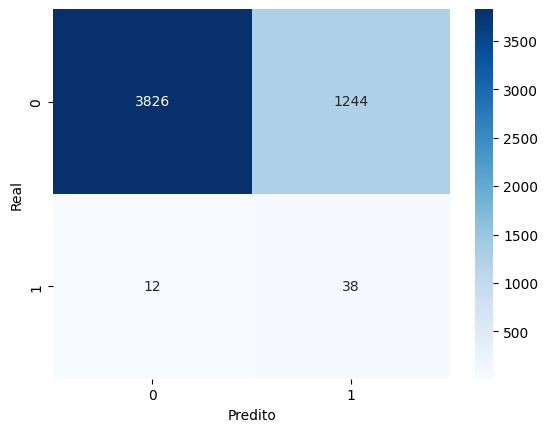

In [77]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=10000, class_weight='balanced')

model.fit(X_train_under, y_train_under)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

avaliar_modelo(y_test, y_pred)

``RandomForestClassifier``

A acurácia de 99% parece bonita, mas o recall tá extremamente baixo

acuracia: 0.4115234375
precisao: 0.016007840574975497
recall: 0.98
roc auc: 0.6929585798816569

              precision    recall  f1-score   support

           0       1.00      0.41      0.58      5070
           1       0.02      0.98      0.03        50

    accuracy                           0.41      5120
   macro avg       0.51      0.69      0.30      5120
weighted avg       0.99      0.41      0.57      5120



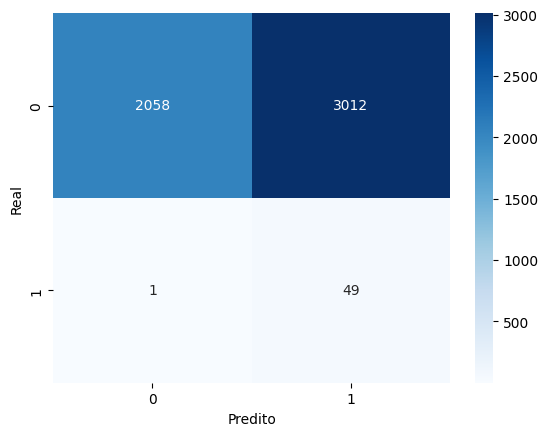

In [78]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight='balanced')

rf.fit(X_train_under, y_train_under)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

threshold = 0.25
y_pred_rf = (y_proba_rf >= threshold).astype(int)

avaliar_modelo(y_test, y_pred_rf)

``XGBClassifier``

acuracia: 0.434765625
precisao: 0.0163265306122449
recall: 0.96
roc auc: 0.6947928994082839

              precision    recall  f1-score   support

           0       1.00      0.43      0.60      5070
           1       0.02      0.96      0.03        50

    accuracy                           0.43      5120
   macro avg       0.51      0.69      0.32      5120
weighted avg       0.99      0.43      0.60      5120



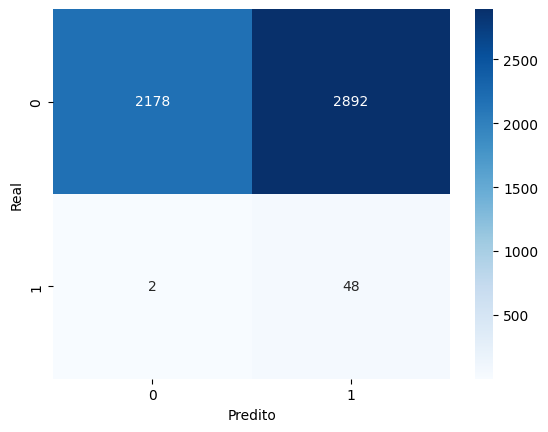

In [79]:
from xgboost import XGBClassifier

scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42, 
    scale_pos_weight=scale_pos_weight)

xgb.fit(X_train_under, y_train_under)
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

avaliar_modelo(y_test, y_pred_xgb)

``GradientBoostingClassifier``

Threshold 0.5: 
- acurácia 0.83
- recall 0.68
- precisão 0.04
- roc 0.75

acuracia: 0.83828125
precisao: 0.04018912529550828
recall: 0.68
roc auc: 0.7599211045364891

              precision    recall  f1-score   support

           0       1.00      0.84      0.91      5070
           1       0.04      0.68      0.08        50

    accuracy                           0.84      5120
   macro avg       0.52      0.76      0.49      5120
weighted avg       0.99      0.84      0.90      5120



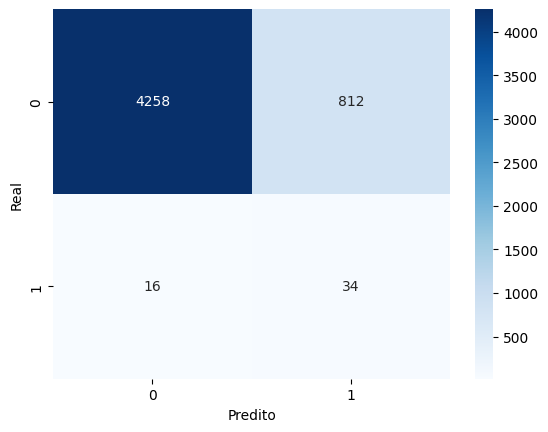

In [80]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42)

gb.fit(X_train, y_train, sample_weight=sample_weights)
y_pred_gb = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]

avaliar_modelo(y_test, y_pred_gb)

### **Testando Thresholds**

Trade off entre acurácia e recall

Como o meu caso o mais importante é **detectar a maioria de casos que vão violar**, o ``recall é o mais importante`` para mim

threshold: 0.2
acuracia: 0.466015625
precisao: 0.017266187050359712
recall: 0.96
roc auc: 0.7105719921104536

              precision    recall  f1-score   support

           0       1.00      0.46      0.63      5070
           1       0.02      0.96      0.03        50

    accuracy                           0.47      5120
   macro avg       0.51      0.71      0.33      5120
weighted avg       0.99      0.47      0.63      5120



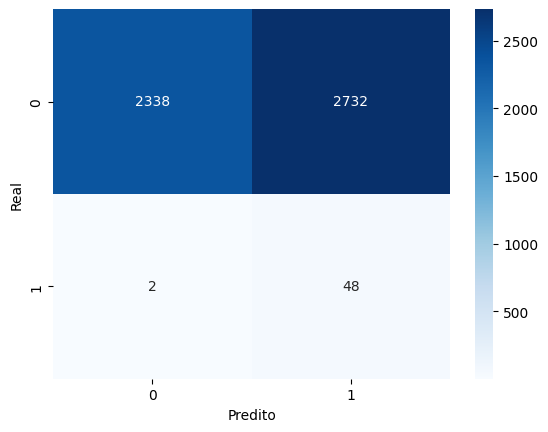

threshold: 0.3
acuracia: 0.582421875
precisao: 0.02110091743119266
recall: 0.92
roc auc: 0.7495463510848126

              precision    recall  f1-score   support

           0       1.00      0.58      0.73      5070
           1       0.02      0.92      0.04        50

    accuracy                           0.58      5120
   macro avg       0.51      0.75      0.39      5120
weighted avg       0.99      0.58      0.73      5120



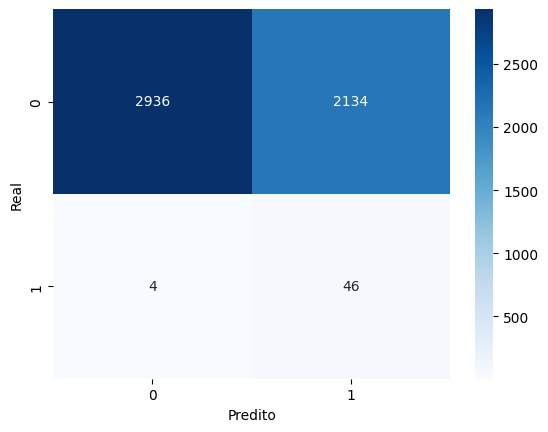

threshold: 0.4
acuracia: 0.70546875
precisao: 0.027849740932642485
recall: 0.86
roc auc: 0.7819723865877711

              precision    recall  f1-score   support

           0       1.00      0.70      0.83      5070
           1       0.03      0.86      0.05        50

    accuracy                           0.71      5120
   macro avg       0.51      0.78      0.44      5120
weighted avg       0.99      0.71      0.82      5120



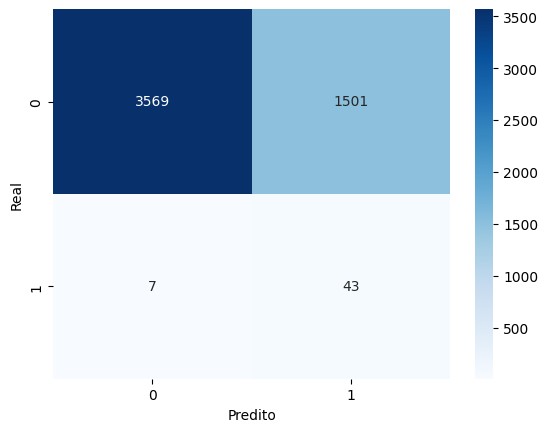

In [81]:
for threshold in [0.2, 0.3, 0.4]:    
    y_pred = (y_proba_gb >= threshold).astype(int)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred)

    print('threshold:', threshold)
    avaliar_modelo(y_test, y_pred)

Para o meu caso, decidi escolher threshold 0.3
- recall 0.92 (extremamente interessante para o objetivo deste modelo)
- acurácia 0.58
- roc auc 0.74

In [82]:
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       1.00      0.84      0.91      5070
           1       0.04      0.68      0.08        50

    accuracy                           0.84      5120
   macro avg       0.52      0.76      0.49      5120
weighted avg       0.99      0.84      0.90      5120



_________________
## **Clusterização de Incidentes**

Clusterização perfil do incidente na abertura (informações existentes antes do fechamento do incidente)

In [425]:
df.head()

,Número,Prioridade,Produto,Categoria,Subcategoria,Grupo designado,Item de configuração,Aberto,Resolvido,Encerrado,Duração,Código de fechamento,Descrição resumida,Solução,Aberto por,Incidente Pai,Status,Entrou para KPI?,KPI Violado?,tem_resolucao,tem_pai,tem_produto,tem_categoria,tem_subcategoria,tem_item_config,tem_CF,kpi_violado,kpi_nao_aplicavel,mes,tem_AM
0,INC8654273,3 - Média,MONITORING_AUTO,INFRA_Monitoramento,INFRA_Monitoramento_Geral,Team14,IC00001,2025-12-31 23:45:18,2025-12-31 23:45:32,2025-12-31 23:45:32,14,AUTO_SEM_INTERVENCAO,Problem: Apache Busy Workers,SEM_SOLUCAO,Monitoramento,NaN,Sem Intervenção,NAO,NAO_APLICAVEL,0,0,0,0,0,1,0,0,1,12,0
1,INC8654270,4 - Baixa,MONITORING_AUTO,INFRA_Monitoramento,INFRA_Monitoramento_Geral,Team14,IC00002,2025-12-31 23:39:36,2025-12-31 23:43:05,2025-12-31 23:43:05,209,AUTO_SEM_INTERVENCAO,Problem: Check Application Monitoring,SEM_SOLUCAO,Monitoramento,NaN,Sem Intervenção,NAO,NAO_APLICAVEL,0,0,0,0,0,1,0,0,1,12,1
2,INC8654264,4 - Baixa,MONITORING_AUTO,INFRA_Monitoramento,INFRA_Monitoramento_Geral,Team14,SEM_IC,2025-12-31 23:23:10,2025-12-31 23:25:00,2025-12-31 23:25:00,110,AUTO_SEM_INTERVENCAO,"Problem: Alarm Application Monitoring database Message: HTTPSConnectionPool(host='centraldoclienteIC04172locawebIC04172comIC04172br', port=443): Read timed out. (read timeout=25)",SEM_SOLUCAO,Monitoramento,NaN,Sem Intervenção,NAO,NAO_APLICAVEL,0,0,0,0,0,0,0,0,1,12,1
3,INC8654263,4 - Baixa,MONITORING_AUTO,INFRA_Monitoramento,INFRA_Monitoramento_Geral,Team14,SEM_IC,2025-12-31 23:23:07,2025-12-31 23:24:57,2025-12-31 23:24:57,110,AUTO_SEM_INTERVENCAO,"Problem: Alarm Application Monitoring coupons Message: HTTPSConnectionPool(host='centraldoclienteIC04172locawebIC04172comIC04172br', port=443): Read timed out. (read timeout=25)",SEM_SOLUCAO,Monitoramento,NaN,Sem Intervenção,NAO,NAO_APLICAVEL,0,0,0,0,0,0,0,0,1,12,1
4,INC8654262,4 - Baixa,MONITORING_AUTO,INFRA_Monitoramento,INFRA_Monitoramento_Geral,Team14,IC00003,2025-12-31 23:23:05,2025-12-31 23:23:47,2025-12-31 23:23:47,42,AUTO_SEM_INTERVENCAO,Problem: Check Application Monitoring,SEM_SOLUCAO,Monitoramento,NaN,Sem Intervenção,NAO,NAO_APLICAVEL,0,0,0,0,0,1,0,0,1,12,1


#### Preparação das variáveis para Clusterização

Criação de variáveis que podem ajudar a capturar padrões.

A variável Item de configuração possui uma grande quantidade de categorias e para reduzir a complexidade (tempo de processamento e etc), foram mantidos apenas os 100 itens mais frequentes.

In [426]:
df_cluster = df.copy()

# disponíveis no momento da abertura
df_cluster['hora_abertura'] = df_cluster['Aberto'].dt.hour
df_cluster['dia_semana'] = df_cluster['Aberto'].dt.dayofweek
df_cluster['fim_de_semana'] = (df_cluster['dia_semana'] >= 5).astype(int)

top_ic = (df_cluster['Item de configuração'].value_counts().head(100).index)
df_cluster['Item_config_cluster'] = (df_cluster['Item de configuração'].where(df_cluster['Item de configuração'].isin(top_ic), 'OUTROS'))

print("Categorias originais:", df_cluster['Item de configuração'].nunique())
print("Categorias utilizadas no clustering:", df_cluster['Item_config_cluster'].nunique())

Categorias originais: 9172
Categorias utilizadas no clustering: 101


### Redução de categorias para melhorar a qualidade dos clusters

Durante a análise dos dados, foi observado que algumas variáveis possuíam uma quantidade muito grande de categorias diferentes, principalmente:
- **Categoria**: 143 valores distintos
- **Subcategoria**: 450 valores distintos

Além disso, algumas categorias apareciam pouquíssimas vezes na base, representando casos muito específicos.
- Tipo a categoria de prioridade Crítica (que só aparece 1 vez)
    - Agrupei com prioridade 2 Alta

In [427]:
top_categoria = df_cluster['Categoria'].value_counts().head(30).index
df_cluster['Categoria_cluster'] = df_cluster['Categoria'].where(df_cluster['Categoria'].isin(top_categoria), 'OUTROS')

top_subcategoria = df_cluster['Subcategoria'].value_counts().head(30).index
df_cluster['Subcategoria_cluster'] = df_cluster['Subcategoria'].where(df_cluster['Subcategoria'].isin(top_subcategoria), 'OUTROS')

df_cluster['Prioridade_cluster'] = df_cluster['Prioridade'].replace({'1 - Crítica': '2 - Alta'})

print("Categoria:", df_cluster['Categoria'].nunique(), "->", df_cluster['Categoria_cluster'].nunique())
print("Subcategoria:", df_cluster['Subcategoria'].nunique(), "->", df_cluster['Subcategoria_cluster'].nunique())
print("Prioridade:", df_cluster['Prioridade'].nunique(), "->", df_cluster['Prioridade_cluster'].nunique())

Categoria: 143 -> 31
Subcategoria: 450 -> 31
Prioridade: 5 -> 4


#### Definição das variáveis utilizadas na clusterização

In [483]:
features_cluster = [
    'Prioridade_cluster',
    'Produto',
    'Categoria_cluster',
    'Subcategoria_cluster',
    'Grupo designado',
    'Item_config_cluster',
    'Aberto por',
    'hora_abertura',
    'dia_semana',
    'fim_de_semana',
    'mes',
    'tem_AM']

X_cluster = df_cluster[features_cluster].copy()

In [484]:
colunas_categoricas = [
    'Prioridade_cluster',
    'Produto',
    'Categoria_cluster',
    'Subcategoria_cluster',
    'Grupo designado',
    'Item_config_cluster',
    'Aberto por'
]

for col in colunas_categoricas:
    print(f"\n{col}: {X_cluster[col].nunique()} categorias")


Prioridade_cluster: 4 categorias

Produto: 53 categorias

Categoria_cluster: 31 categorias

Subcategoria_cluster: 31 categorias

Grupo designado: 17 categorias

Item_config_cluster: 101 categorias

Aberto por: 2 categorias


#### One hot Encoding

In [485]:
X_cluster_encoded = pd.get_dummies(X_cluster, columns=colunas_categoricas, drop_first=False)
print("Shape após One-Hot:", X_cluster_encoded.shape)

Shape após One-Hot: (122543, 244)


#### Standard Scaler

Sem a padronização, variáveis com amplitudes maiores poderiam exercer influência desproporcional no cálculo das distâncias utilizadas pelo algoritmo.

In [486]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster_encoded)
print("Shape final:", X_cluster_scaled.shape)

Shape final: (122543, 244)


#### Definição da amostra para avaliação dos clusters
Antes de determinar a quantidade ideal de clusters, foi criada uma amostra dos dados para realizar os testes de forma mais eficiente.

Para acelerar essa etapa exploratória, foi utilizada uma amostra representativa dos registros.

In [487]:
from sklearn.cluster import KMeans

# amostra para avaliação do número de clusters (k)
sample_size = min(15000, X_cluster_scaled.shape[0])
rng = np.random.RandomState(42)

sample_indices = rng.choice(X_cluster_scaled.shape[0], size=sample_size, replace=False)

X_cluster_sample = X_cluster_scaled[sample_indices]
print("Tamanho da amostra:", X_cluster_sample.shape)

Tamanho da amostra: (15000, 244)


### **Encontrar um bom número de clusters (k)**

#### **Método 1 - Elbow (cotovelo)**

A análise consiste em executar o algoritmo K-Means para diferentes valores de K (número de clusters) e medir a inércia de cada solução.
- Valores menores indicam grupos mais homogêneos
- Quanto maior a redução da inércia ao aumentar o número de clusters, maior o ganho na capacidade de segmentação

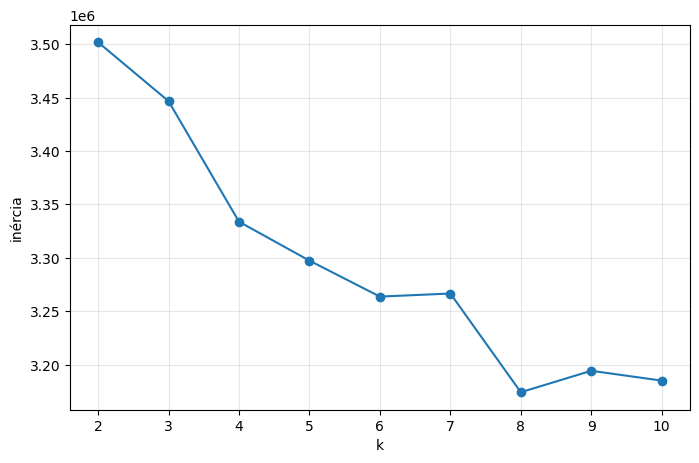

In [488]:
inercia = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=5)
    kmeans.fit(X_cluster_sample)
    inercia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inercia, marker='o')
plt.xlabel('k')
plt.ylabel('inércia')
plt.xticks(K)
plt.grid(True, alpha=0.3)
plt.show()

Interpretação:

O gráfico mostra uma redução significativa da inércia entre **2 e 4 clusters**, indicando que os primeiros agrupamentos capturam boa parte da estrutura dos dados.

A partir desse ponto, a curva passa a apresentar uma redução mais gradual, sugerindo uma diminuição do benefício obtido ao adicionar novos grupos.

__________
#### **Método 2 - Silhouette Score**

Após a análise inicial utilizando o Método do Cotovelo, foi aplicada uma segunda métrica para avaliar a qualidade dos agrupamentos: o **Silhouette Score**.

O Silhouette Score mede o quanto cada registro está:
- Próximo dos elementos do seu próprio cluster
- Distante dos elementos dos demais clusters

``Quanto maior o valor, melhor a separação entre os grupos``

- Próximo de 1 -> clusters bem definidos e separados.
- Próximo de 0 -> clusters com sobreposição significativa.
- Valores negativos -> indício de agrupamentos inadequados.

In [489]:
from sklearn.metrics import silhouette_score
silhouette_scores = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=5)
    labels = kmeans.fit_predict(X_cluster_sample)

    score = silhouette_score(X_cluster_sample, labels)
    silhouette_scores.append(score)

for k, score in zip(K, silhouette_scores):
    print(f"k = {k}: Silhouette Score = {score:.4f}")

k = 2: Silhouette Score = 0.1844
k = 3: Silhouette Score = 0.4648
k = 4: Silhouette Score = 0.0973
k = 5: Silhouette Score = 0.1857
k = 6: Silhouette Score = 0.1430
k = 7: Silhouette Score = 0.1526
k = 8: Silhouette Score = 0.1335
k = 9: Silhouette Score = 0.0667
k = 10: Silhouette Score = -0.1486


O melhor resultado foi obtido com **K = 3**, alcançando um Silhouette Score de **0,4648**, valor significativamente superior aos demais cenários testados.

______________
#### Avaliação da redução de dimensionalidade com PCA

Após a preparação dos dados, foi realizado um teste com **PCA (Principal Component Analysis)** para avaliar a possibilidade de reduzir a quantidade de variáveis antes da clusterização

PCA transforma as variáveis originais em um conjunto menor de componentes (preservando partes importantes)

Resultado:
- Foi definido que o PCA deveria preservar **90% da variância total dos dados**
- Mesmo preservando apenas 90% da variância, ainda são necessários **169 componentes** para representar adequadamente a estrutura da base
- redução obtida foi relativamente pequena

In [481]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.90, random_state=42)  # mantém 90% da variância
X_cluster_pca = pca.fit_transform(X_cluster_scaled)

print(f"Dimensões originais: {X_cluster_scaled.shape[1]}")
print(f"Componentes para explicar 90% da variância: {X_cluster_pca.shape[1]}")

Dimensões originais: 193
Componentes para explicar 90% da variância: 146


_______________
### Definição do modelo final de clusterização

Com base nas análises realizadas anteriormente, foi definido **K = 3** como a quantidade de clusters para o modelo final.

Essa decisão foi baseada principalmente nos resultados do **Silhouette Score**

Resultados:
- **Cluster 0** concentra a maior parte dos chamados da base, representando aproximadamente dois terços dos registros.
- **Cluster 1** possui um volume intermediário e pode representar um perfil operacional distinto do grupo principal.
- **Cluster 2** é o menor dos grupos identificados, indicando um conjunto mais específico de chamados com características próprias.

In [490]:
K_FINAL = 3
kmeans_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans_final.fit_predict(X_cluster_scaled)

df_cluster['cluster'].value_counts().sort_index()

cluster
0    77719
1    31494
2    13330
Name: count, dtype: int64

### **O que cada Cluster representa?**

##### Cluster 0 - Chamados gerados por monitoramento
Principais características:
- 77.719 chamados
- 100% dos registros originados por monitoramento
- Maior concentração de chamados de baixa prioridade
- 71% classificados como "4 - Baixa"
- 45% dos registros associados a AM
- Categoria predominante: **INFRA_Monitoramento** (100%)

##### Cluster 1 - Chamados operacionais gerais
Principais características:
- 31.494 chamados
- Distribuição equilibrada entre abertura manual (49%) e monitoramento (51%)
- Predominância de prioridade média (63%)
- Baixa presença de AM (2%)
- Não existe uma única categoria dominante, indicando maior diversidade de assuntos

##### Cluster 2 - Chamados especializados
Principais características:
- 13.330 chamados.
- Predominância de monitoramento (79%)
- Maior participação de chamados de alta prioridade
- 29% classificados como "2 - Alta"
- Forte concentração em categorias específicas:
    - cat71 (53,4%)
    - cat73 (23,9%)
    - cat137 (11,7%)

In [117]:
perfil_numerico = df_cluster.groupby('cluster')[['hora_abertura', 'dia_semana', 'fim_de_semana', 'tem_AM']].mean().round(2)
print("Perfil médio (variáveis numéricas) por cluster:")
print(perfil_numerico)

Perfil médio (variáveis numéricas) por cluster:
         hora_abertura  dia_semana  fim_de_semana  tem_AM
cluster                                                  
0                11.37        2.88           0.26    0.45
1                12.21        2.47           0.14    0.02
2                11.33        2.62           0.20    0.00


In [118]:
print("\nDistribuição de Prioridade por cluster (%):")
print(pd.crosstab(df_cluster['cluster'], df_cluster['Prioridade'], normalize='index').round(2) * 100)


Distribuição de Prioridade por cluster (%):
Prioridade  1 - Crítica  2 - Alta  3 - Média  4 - Baixa  5 - Muito Baixa
cluster                                                                 
0                   0.0       7.0       22.0       71.0              0.0
1                   0.0      20.0       63.0       17.0              0.0
2                   0.0      29.0       39.0       31.0              2.0


In [119]:
print("\nAberto por (Manual vs Monitoramento) por cluster (%):")
print(pd.crosstab(df_cluster['cluster'], df_cluster['Aberto por'], normalize='index').round(2) * 100)


Aberto por (Manual vs Monitoramento) por cluster (%):
Aberto por  Manual  Monitoramento
cluster                          
0              0.0          100.0
1             49.0           51.0
2             21.0           79.0


In [120]:
print("\nTop 3 Categorias por cluster:")
for c in sorted(df_cluster['cluster'].unique()):
    print(f"\nCluster {c} (n={ (df_cluster['cluster'] == c).sum() }):")
    print(df_cluster[df_cluster['cluster'] == c]['Categoria_cluster'].value_counts(normalize=True).head(3).round(3) * 100)


Top 3 Categorias por cluster:

Cluster 0 (n=77719):
Categoria_cluster
INFRA_Monitoramento    100.0
cat77                    0.0
Name: proportion, dtype: float64

Cluster 1 (n=31494):
Categoria_cluster
OUTROS    14.0
cat77     14.0
cat85     13.7
Name: proportion, dtype: float64

Cluster 2 (n=13330):
Categoria_cluster
cat71     53.4
cat73     23.9
cat137    11.7
Name: proportion, dtype: float64
